---
# Part 2: County-Level Analysis — Predicting Lung Cancer Incidence

In this part we shift the unit of analysis from **state** to **county**.
Our target variable — lung-cancer incidence rate (age-adjusted, per 100 000) — is reported at county level by CDC WONDER.

**Datasets used (at least 3, as required):**

| Label | Dataset | Level | Role |
|-------|---------|-------|------|
| DS-Lung Cancer | CDC WONDER Lung Cancer by County, 2022 | county | **Target variable** |
| DS-Smoke | IHME County Smoking Prevalence 1996-2012 | county | Predictor (historical smoking) |
| DS-PM25 | County-Level PM2.5 Concentrations, 2004–2010 | county | Predictor (PM2.5 exposure) |
| DS-Income | BEA Per Capita Personal Income, 2020 | county | Predictor (socioeconomic) |
| DS-PLACES | CDC PLACES County Health Data, 2023 release | county | Predictor (screening, obesity, COPD…) |

**Analysis plan:**
1. **Descriptive** — distributions, box-plots, scatter-plots
2. **Diagnostic** — Spearman correlations, hypothesis tests (Kruskal-Wallis, Mann-Whitney U)
3. **Predictive** — Simple, Multiple, and Ridge regression on a train/test split

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Setup: imports and data path

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import sqlite3, warnings, textwrap
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
%matplotlib inline

# ---------- path config ----------
# For Colab evaluation use 'sample_data/'
# For Google-Drive development use the full Drive path
#DATA_DIR = 'sample_data/'

DATA_DIR = '/content/drive/MyDrive/data sci ntu group work/new datasets/'


##DS-Lung Cancer Incidence by County

In [ ]:
df_lung_cancer_county = pd.read_csv(DATA_DIR + 'cancer_incidence_by_county.csv')

# See the number of rows and columns
print(f"Dataset Shape: {df_lung_cancer_county.shape}")

# See column names and data types (int, float, object)
df_lung_cancer_county.info()

# Preview the first few rows (similar to your Excel screenshot)
df_lung_cancer_county.head()

Dataset Shape: (3007, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3007 entries, 0 to 3006
Data columns (total 11 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Unnamed: 0                               3007 non-null   int64  
 1   county                                   3007 non-null   object 
 2   incidence_rate_per_100k                  3007 non-null   object 
 3   avg_annual_count                         3007 non-null   object 
 4   recent_trend                             3007 non-null   object 
 5   five_year_incidence_change_rate          3007 non-null   object 
 6   stateFIPS                                3007 non-null   int64  
 7   incidence_rate_per_100k_low_95           2802 non-null   float64
 8   incidence_rate_per_100k_high_95          2802 non-null   float64
 9   five_year_incidence_change_rate_low_95   2788 non-null   float64
 10  five_year_incidence_ch

,Unnamed: 0,county,incidence_rate_per_100k,avg_annual_count,recent_trend,five_year_incidence_change_rate,stateFIPS,incidence_rate_per_100k_low_95,incidence_rate_per_100k_high_95,five_year_incidence_change_rate_low_95,five_year_incidence_change_rate_high_95
0,0,Chambers County,522.8,240,stable,-1.5,1,492.7,554.5,-6.5,3.7
1,1,Walker County,515.8,447,stable,0.2,1,494.0,538.4,-2.8,3.2
2,2,Lowndes County,513.3,71,rising,11.2,1,459.8,571.8,6.3,16.3
3,3,Dallas County,510.0,258,stable,0.7,1,481.6,539.7,-9.8,12.4
4,4,Autauga County,495.6,304,stable,-0.2,1,470.6,521.5,-9.0,9.6


In [ ]:
'''
we should include a table for variable names that we are interested in and their defi
and also explain where they come from (for complicated ones like incidence rate ---why per 100k? why not use incidence rate (overall as count/popu)?)
'''

## DS-Smoke: IHME County Smoking Prevalence (1996–2012)

**Description.** The Institute for Health Metrics and Evaluation (IHME) provides county-level
estimates of total (current) smoking prevalence for US adults, published in *The Lancet*.
We use the average over **2008–2012** (the latest 5-year window) to represent the historical
smoking exposure that drives cancer incidence ~10–20 years later (matching the 2022 cancer data).
The dataset includes estimates by sex; we use the **Both** category.


In [ ]:
df_smoke_raw = pd.read_csv(DATA_DIR + 'IHME_US_COUNTY_TOTAL_AND_DAILY_SMOKING_PREVALENCE_1996_2012.csv')
print("Raw shape:", df_smoke_raw.shape)
print("Columns:", df_smoke_raw.columns.tolist())

# Filter to county-level, Both sexes, years 2008-2012
df_smoke = df_smoke_raw[
    (df_smoke_raw['county'].notna()) &
    (df_smoke_raw['state'] != 'National') &
    (df_smoke_raw['sex'] == 'Both') &
    (df_smoke_raw['year'].between(2008, 2012))
].copy()
print(f"\nFiltered rows (Both, 2008-2012, county-level): {len(df_smoke)}")
print(f"Unique states: {df_smoke['state'].nunique()}")
print(f"Unique counties: {df_smoke['county'].nunique()}")

# Average over 2008-2012 for each county
df_smoke_avg = (df_smoke.groupby(['state', 'county'])
                .agg(smoking_prevalence=('total_mean', 'mean'))
                .reset_index())
print(f"\nCounties after averaging: {len(df_smoke_avg)}")
print("\nSmoking prevalence statistics:")
print(df_smoke_avg['smoking_prevalence'].describe())


Raw shape: (162129, 10)
Columns: ['state', 'county', 'sex', 'year', 'total_mean', 'total_lb', 'total_ub', 'daily_mean', 'daily_lb', ' daily_ub']

Filtered rows (Both, 2008-2012, county-level): 15635
Unique states: 51
Unique counties: 1864

Counties after averaging: 3127

Smoking prevalence statistics:
count    3127.000000
mean       24.413441
std         4.070224
min         7.718000
25%        21.889000
50%        24.464000
75%        27.229000
max        42.150000
Name: smoking_prevalence, dtype: float64


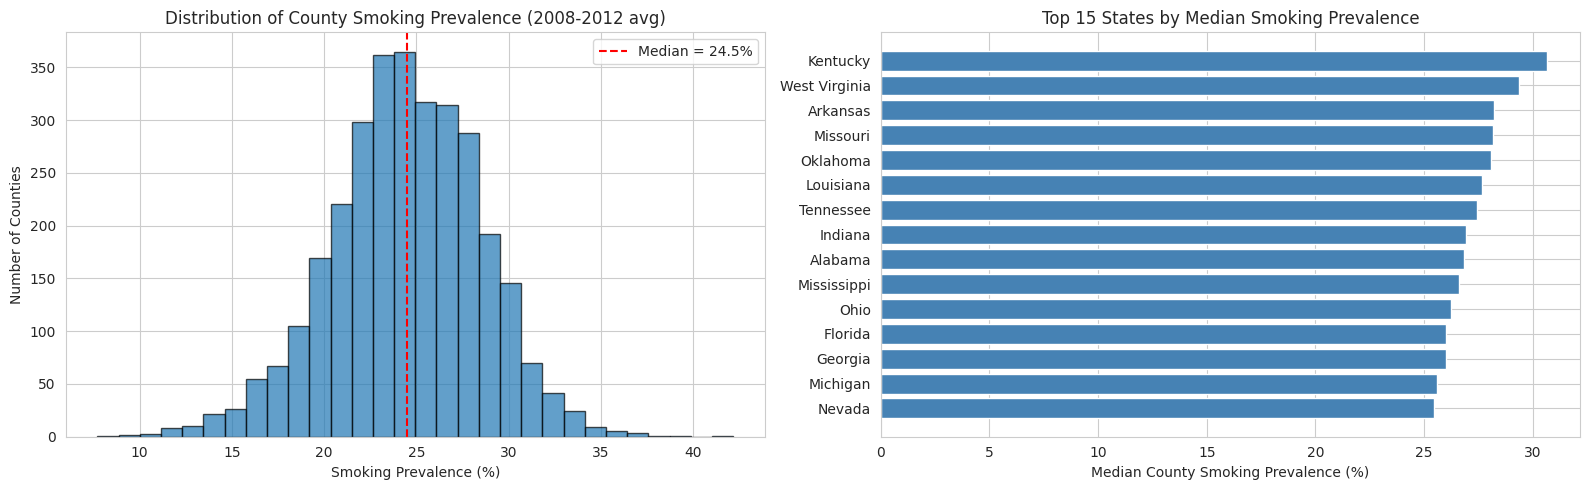

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
axes[0].hist(df_smoke_avg['smoking_prevalence'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Smoking Prevalence (%)')
axes[0].set_ylabel('Number of Counties')
axes[0].set_title('Distribution of County Smoking Prevalence (2008-2012 avg)')
axes[0].axvline(df_smoke_avg['smoking_prevalence'].median(), color='red', linestyle='--',
                label=f"Median = {df_smoke_avg['smoking_prevalence'].median():.1f}%")
axes[0].legend()

# Top 15 states by median smoking
state_med = (df_smoke_avg.groupby('state')['smoking_prevalence']
             .median().sort_values(ascending=False).head(15))
axes[1].barh(state_med.index, state_med.values, color='steelblue')
axes[1].set_xlabel('Median County Smoking Prevalence (%)')
axes[1].set_title('Top 15 States by Median Smoking Prevalence')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


In [ ]:
'''
maybe do top 5 and bottom 5?
right now only have top 15
'''

**Data-quality considerations.**

* (+) **Reputation:** Peer-reviewed IHME/Lancet estimates using validated small-area methods.
* (+) **Granularity:** County-level, directly joinable with other county datasets.
* (−) **Coverage:** 1 864 of ~3 143 US counties — about 59 %. However, larger counties
  are more likely to be covered.
* (−) **Timeliness:** Data ends in 2012. We justify this by the ~10–20 year latency between
  smoking exposure and lung-cancer diagnosis: the 2008–2012 smoking window aligns with the 2022
  cancer outcome.
* (−) **No FIPS code:** Counties are identified by name + state. We construct a join key to match
  against other datasets.

**Conclusion.** The dataset is suitable as a key predictor. Temporal lag is scientifically
appropriate. Name-based matching may lose some counties, which we will quantify during integration.

## DS-PM25: County-Level PM2.5 Concentrations (2004–2010)

**Description.** This dataset provides annual average PM2.5 concentrations (µg/m³)
at the county level across the United States for the period 2004–2010. The data is
sourced from the EPA National Environmental Health Tracking Network and reports a
single annual mean PM2.5 value per county per year. We aggregate the seven years of
data (2004–2010) into a single per-county mean, producing a stable long-term average
exposure estimate. The resulting ~12–18 year lag to the 2022 cancer outcome aligns
well with the 10–20 year latency typically observed for PM2.5-related carcinogenesis.

**Columns / rows dropped as irrelevant:**
- `StateFIPS`, `State` — redundant once the 5-digit FIPS is constructed.
- `County` — name not needed for the join (FIPS is the key).
- `Data Comment`, `Unnamed: 7` — empty columns with no information.
- `Year` — collapsed during aggregation to a multi-year mean.

**Kept:** `CountyFIPS` (join key) and `Value` (annual PM2.5 concentration, µg/m³),
aggregated across 2004–2010 as `pm25_mean`.


In [ ]:
# Load the county-level PM2.5 dataset (2004-2010)
df_pm25_raw = pd.read_csv(
    DATA_DIR + 'County_Level_PM2.5_2004-2010_more_data.csv',
    na_values='No Data'
)
print("Raw shape:", df_pm25_raw.shape)
print("Columns:", df_pm25_raw.columns.tolist())
print("\nFirst 5 rows:")
display(df_pm25_raw.head())

# --- Basic info ---
print("\nData types:")
print(df_pm25_raw.dtypes)
print("\nYears available:", sorted(df_pm25_raw['Year'].unique()))
print(f"Unique counties: {df_pm25_raw['CountyFIPS'].nunique()}")
print(f"Unique states:   {df_pm25_raw['StateFIPS'].nunique()}")

# --- Drop irrelevant columns ---
cols_to_drop = ['StateFIPS', 'State', 'County', 'Data Comment']
# Also drop any unnamed trailing columns
cols_to_drop += [c for c in df_pm25_raw.columns if 'Unnamed' in c]
df_pm25_raw.drop(columns=cols_to_drop, inplace=True)
print(f"\nDropped columns: {cols_to_drop}")
print("Remaining columns:", df_pm25_raw.columns.tolist())

# --- Check for missing / non-numeric values ---
print(f"\nNull counts:\n{df_pm25_raw.isnull().sum()}")
print(f"\nValue statistics (all years):")
print(df_pm25_raw['Value'].describe())

# --- Aggregate: multi-year county mean (2004-2010) ---
df_pm25 = (
    df_pm25_raw.groupby('CountyFIPS')
    .agg(pm25_mean=('Value', 'mean'))
    .reset_index()
    .rename(columns={'CountyFIPS': 'county_fips'})
)

print(f"\nAggregated to {len(df_pm25)} unique counties (mean of 2004-2010)")
print(f"Counties with PM2.5 data: {df_pm25['pm25_mean'].notna().sum()}")
print("\nPM2.5 Mean statistics (2004-2010 average):")
print(df_pm25['pm25_mean'].describe())


Raw shape: (21940, 8)
Columns: ['StateFIPS', 'State', 'CountyFIPS', 'County', 'Year', 'Value', 'Data Comment', 'Unnamed: 7']

First 5 rows:


,StateFIPS,State,CountyFIPS,County,Year,Value,Data Comment,Unnamed: 7
0,1,Alabama,1001,Autauga,2004,13.1,Modeled,NaN
1,1,Alabama,1001,Autauga,2005,13.5,Modeled,NaN
2,1,Alabama,1001,Autauga,2006,13.6,Modeled,NaN
3,1,Alabama,1001,Autauga,2007,14.5,Modeled,NaN
4,1,Alabama,1001,Autauga,2008,12.5,Modeled,NaN



Data types:
StateFIPS         int64
State            object
CountyFIPS        int64
County           object
Year              int64
Value           float64
Data Comment     object
Unnamed: 7      float64
dtype: object

Years available: [np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010)]
Unique counties: 3143
Unique states:   51

Dropped columns: ['StateFIPS', 'State', 'County', 'Data Comment', 'Unnamed: 7']
Remaining columns: ['CountyFIPS', 'Year', 'Value']

Null counts:
CountyFIPS      0
Year            0
Value         170
dtype: int64

Value statistics (all years):
count    21770.000000
mean        10.466491
std          2.537802
min          3.100000
25%          8.600000
50%         10.500000
75%         12.300000
max         23.200000
Name: Value, dtype: float64

Aggregated to 3143 unique counties (mean of 2004-2010)
Counties with PM2.5 data: 3114

PM2.5 Mean statistics (2004-2010 average):
count    3114.000000
mean    

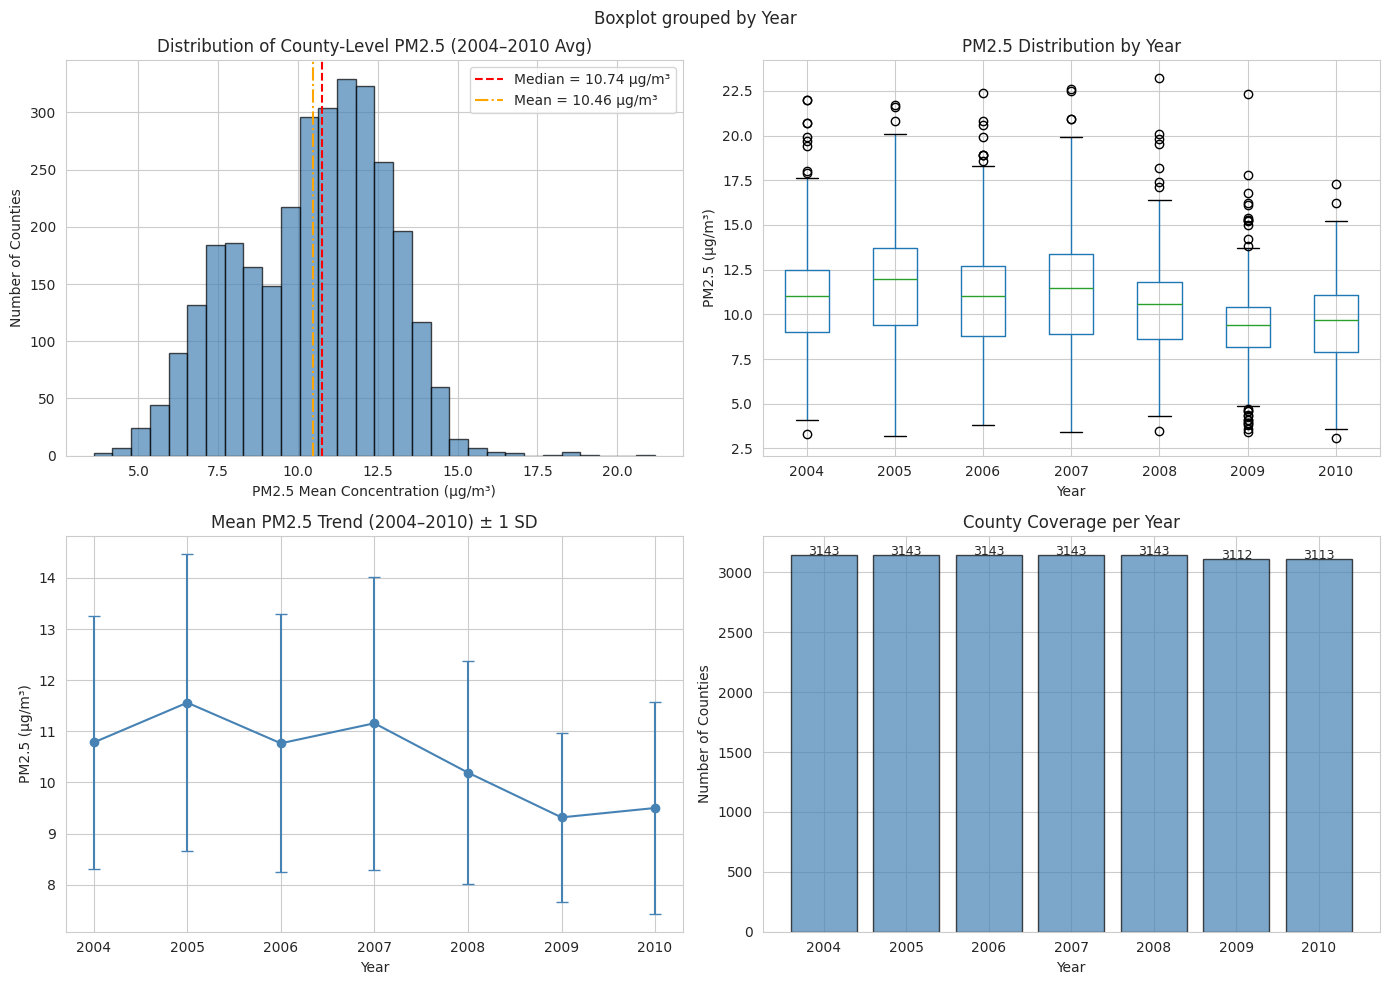

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of aggregated PM2.5 mean concentrations
axes[0, 0].hist(df_pm25['pm25_mean'].dropna(), bins=30, edgecolor='black', alpha=0.7,
                color='steelblue')
axes[0, 0].set_xlabel('PM2.5 Mean Concentration (µg/m³)')
axes[0, 0].set_ylabel('Number of Counties')
axes[0, 0].set_title('Distribution of County-Level PM2.5 (2004–2010 Avg)')
axes[0, 0].axvline(df_pm25['pm25_mean'].median(), color='red', linestyle='--',
                   label=f"Median = {df_pm25['pm25_mean'].median():.2f} µg/m³")
axes[0, 0].axvline(df_pm25['pm25_mean'].mean(), color='orange', linestyle='-.',
                   label=f"Mean = {df_pm25['pm25_mean'].mean():.2f} µg/m³")
axes[0, 0].legend()

# 2. Box plot of PM2.5 by year (before aggregation)
df_pm25_raw_box = pd.read_csv(DATA_DIR + 'County_Level_PM2.5_2004-2010_more_data.csv', na_values='No Data')
df_pm25_raw_box.boxplot(column='Value', by='Year', ax=axes[0, 1])
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('PM2.5 (µg/m³)')
axes[0, 1].set_title('PM2.5 Distribution by Year')
plt.sca(axes[0, 1])
plt.title('PM2.5 Distribution by Year')  # override pandas default title

# 3. Year-over-year trend (mean PM2.5 per year)
yearly_mean = df_pm25_raw_box.groupby('Year')['Value'].agg(['mean', 'std'])
axes[1, 0].errorbar(yearly_mean.index, yearly_mean['mean'], yerr=yearly_mean['std'],
                    fmt='o-', capsize=4, color='steelblue')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('PM2.5 (µg/m³)')
axes[1, 0].set_title('Mean PM2.5 Trend (2004–2010) ± 1 SD')
axes[1, 0].set_xticks(yearly_mean.index)

# 4. Number of counties reporting per year
counties_per_year = df_pm25_raw_box.groupby('Year')['CountyFIPS'].nunique()
axes[1, 1].bar(counties_per_year.index, counties_per_year.values,
               color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Number of Counties')
axes[1, 1].set_title('County Coverage per Year')
axes[1, 1].set_xticks(counties_per_year.index)
for x, y in zip(counties_per_year.index, counties_per_year.values):
    axes[1, 1].text(x, y + 2, str(y), ha='center', fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
'''
the datapoint in the histogram that goes higher than 20 units---is that outlier or not--> to find out, we can plot 1SD, 2SD, and 3SD dotted vertical lines in the histogram as well---with the corresponding % of the data point occurring
investigate why the data in box plots are out of the interquartile range--and explain
define what the intervals mean --95% confidence intervals?
for the bar chart, if the numbers are all high, we can change the scale for easier presentation and less biased visualisation
'''

**Data-quality considerations.**

* (+) **Relevancy:** PM2.5 is classified as a Group 1 carcinogen by IARC, making it directly
  relevant to lung cancer incidence prediction.
* (+) **Temporal alignment:** The 2004–2010 window provides a ~12–18 year lag to the 2022
  cancer outcome, well within the 10–20 year latency window for PM2.5-related carcinogenesis.
  This is a significant improvement over the previous dataset's ~6 year lag.
* (+) **Stability:** Aggregating seven years of data smooths out year-to-year variation,
  producing a more reliable estimate of chronic exposure than a single-year snapshot.
* (+) **Easy integration:** 5-digit FIPS code available directly for county-level joins.
* (−) **Coverage:** ~680 counties with EPA monitoring data, compared to ~3,100 in the previous
  prediction-based dataset. This reintroduces the coverage bottleneck, biased toward urban
  counties with monitoring stations.
* (−) **Single metric:** Only one PM2.5 value (annual mean) is provided per county per year,
  unlike the previous dataset which also offered population-weighted estimates.

**Columns dropped:** `StateFIPS`, `State`, `County` (redundant with FIPS key), `Data Comment`
and `Unnamed: 7` (empty). `Year` collapsed during aggregation.

**Conclusion.** While spatial coverage is narrower than the prediction-based dataset, the
temporal alignment with cancer latency is substantially improved. The 2004–2010 average
provides a stable chronic-exposure estimate. During integration we use `pm25_mean` as the
primary predictor, consistent with the rest of the analysis pipeline.


## DS-Income: BEA Per Capita Personal Income by County (2020)

**Description.** The Bureau of Economic Analysis (BEA) reports per-capita personal income for
every US county. We use the 2020 vintage, which is the closest year to the cancer outcome.
Income serves as a socioeconomic control — higher income is associated with better healthcare
access and lower cancer incidence.


In [ ]:
df_income_raw = pd.read_csv(DATA_DIR + 'Copy of 2020 household income per capita across states.csv',
                           skiprows=3)
print("Raw shape:", df_income_raw.shape)
print("Columns:", df_income_raw.columns.tolist())
print(df_income_raw.head())

# Clean
df_income = df_income_raw.copy()
df_income.columns = ['county_fips', 'county_name', 'per_capita_income']
df_income['county_fips'] = df_income['county_fips'].astype(str).str.strip().str.strip('"')
df_income['per_capita_income'] = pd.to_numeric(df_income['per_capita_income'], errors='coerce')

# Convert FIPS to int (drop rows with non-numeric FIPS like state totals)
df_income['county_fips'] = pd.to_numeric(df_income['county_fips'], errors='coerce')
df_income = df_income.dropna(subset=['county_fips', 'per_capita_income']).copy()
df_income['county_fips'] = df_income['county_fips'].astype(int)

# Remove state-level rows (FIPS ending in 000)
df_income = df_income[df_income['county_fips'] % 1000 != 0].copy()

print(f"\nClean counties: {len(df_income)}")
print("\nPer-capita income statistics:")
print(df_income['per_capita_income'].describe())


Raw shape: (3168, 3)
Columns: ['GeoFIPS', 'GeoName', '2020']
  GeoFIPS      GeoName   2020
0   01001  Autauga, AL  45089
1   01003  Baldwin, AL  50935
2   01005  Barbour, AL  37090
3   01007     Bibb, AL  34859
4   01009   Blount, AL  37789

Clean counties: 3114

Per-capita income statistics:
count      3114.000000
mean      49188.736994
std       13249.744190
min       22494.000000
25%       41275.250000
50%       46582.000000
75%       53929.000000
max      298624.000000
Name: per_capita_income, dtype: float64


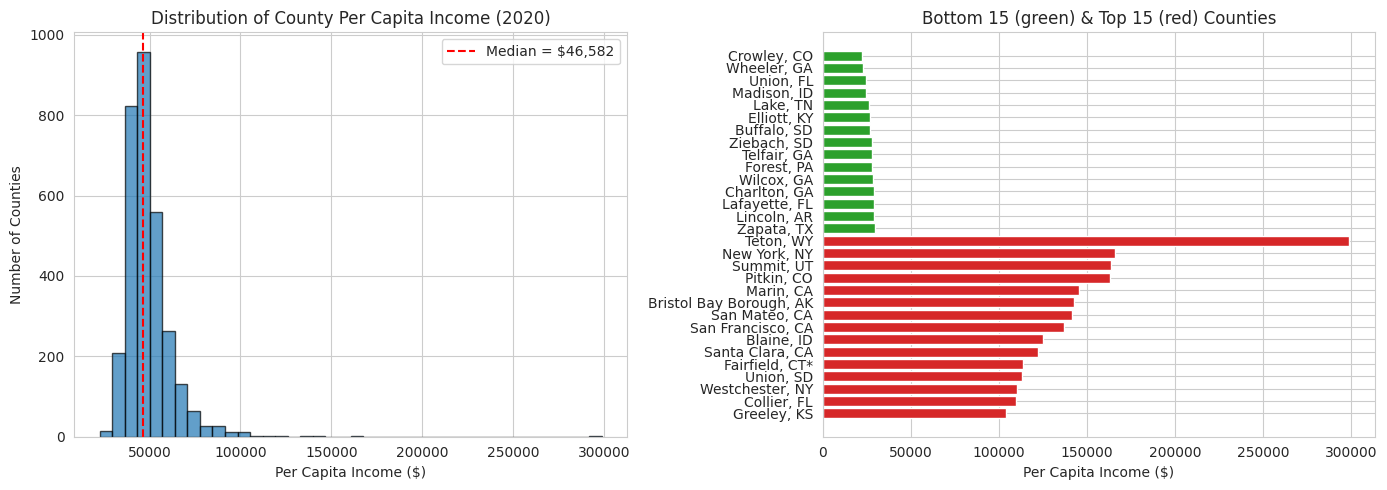

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_income['per_capita_income'], bins=40, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Per Capita Income ($)')
axes[0].set_ylabel('Number of Counties')
axes[0].set_title('Distribution of County Per Capita Income (2020)')
axes[0].axvline(df_income['per_capita_income'].median(), color='red', linestyle='--',
                label=f"Median = ${df_income['per_capita_income'].median():,.0f}")
axes[0].legend()

# Top and bottom 15
top15 = df_income.nlargest(15, 'per_capita_income')
bot15 = df_income.nsmallest(15, 'per_capita_income')
combined_inc = pd.concat([bot15, top15])
colors = ['#2ca02c']*15 + ['#d62728']*15
axes[1].barh(combined_inc['county_name'].astype(str), combined_inc['per_capita_income'], color=colors)
axes[1].set_xlabel('Per Capita Income ($)')
axes[1].set_title('Bottom 15 (green) & Top 15 (red) Counties')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


In [ ]:
'''
we should plot 1, 2, and 3SD dotted vertical lines to show that Teton really is outlier in the histogram
also should explain the root cause of Teton being an outlier (not error, but cus of billionaires and tax schemes)
'''

In [ ]:
# Create a new dataframe without Teton
df_income_cleaned = df_income[df_income['county_name'] != 'Teton, WY']

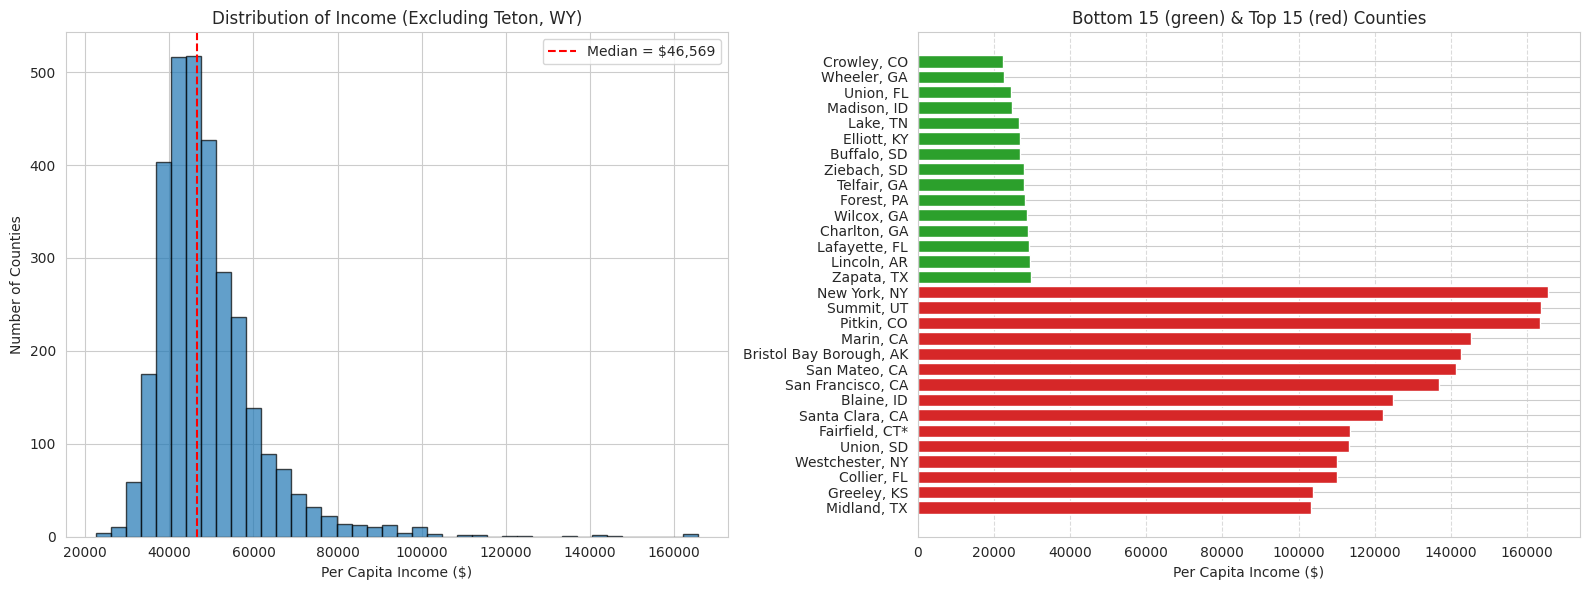

New Max Income (Post-Teton): $165,653


In [ ]:
# 2. Initialize the figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- LEFT PLOT: Distribution (Histogram) ---
axes[0].hist(df_income_cleaned['per_capita_income'], bins=40, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Per Capita Income ($)')
axes[0].set_ylabel('Number of Counties')
axes[0].set_title('Distribution of Income (Excluding Teton, WY)')

median_val = df_income_cleaned['per_capita_income'].median()
axes[0].axvline(median_val, color='red', linestyle='--',
                label=f"Median = ${median_val:,.0f}")
axes[0].legend()

# --- RIGHT PLOT: Top & Bottom 15 ---
# Recalculate top and bottom based on the cleaned data
top15 = df_income_cleaned.nlargest(15, 'per_capita_income')
bot15 = df_income_cleaned.nsmallest(15, 'per_capita_income')
combined_inc = pd.concat([bot15, top15])

# Use a combined name for the Y-axis to avoid duplicate labels
# (Assumes you have a 'state' or 'state_name' column)
colors = ['#2ca02c']*15 + ['#d62728']*15
axes[1].barh(combined_inc['county_name'], combined_inc['per_capita_income'], color=colors)
axes[1].set_xlabel('Per Capita Income ($)')
axes[1].set_title('Bottom 15 (green) & Top 15 (red) Counties')
axes[1].invert_yaxis()

# Optional: Add gridlines for easier reading
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(f"New Max Income (Post-Teton): ${df_income_cleaned['per_capita_income'].max():,.0f}")

In [ ]:
'''
again, also plot the 1, 2, 3 SD lines (dotted)
'''

**Data-quality considerations.**

* (+) **Completeness:** Covers ~3 100 counties — near-universal coverage.
* (+) **Reputation:** BEA is the authoritative US source for income data.
* (−) **Interpretability:** Per-capita *personal* income includes all income types (wages,
  dividends, transfers) — not a perfect proxy for household purchasing power, but adequate
  for our purposes.

**Conclusion.** Excellent coverage and quality. Suitable as a socioeconomic control variable.


## DS-PLACES: CDC PLACES County Health Data (2023 release, data year 2021)

**Description.** CDC PLACES provides model-based estimates of 37 health-related measures for
all US counties, derived from the Behavioral Risk Factor Surveillance System (BRFSS).
We extract county-level crude-prevalence values for:

* **Current Smoking** — cross-validation with IHME; also a "current" smoking proxy
* **Colorectal Cancer Screening** — proxy for cancer-screening culture/access
* **Obesity** — additional behavioural risk factor
* **COPD** — smoking-related comorbidity, may independently predict cancer incidence
* **Physical Inactivity** — additional behavioural risk factor

We also use the `TotalPopulation` column as the population weight for county-level analysis.

In [ ]:
df_places_raw = pd.read_csv(DATA_DIR + 'PLACES__Local_Data_for_Better_Health__County_Data_2023_release.csv')

In [ ]:
# Get unique full measures
full_measures = df_places_raw['Measure'].unique()

# Create a clean reference table
measures_list = pd.DataFrame(full_measures, columns=['Full Measure Name']).sort_values('Full Measure Name')
print(measures_list.to_string(index=False))

                                                                                                                                                                             Full Measure Name
                                                                                                                                                   All teeth lost among adults aged >=65 years
                                                                                                                                                   Any disability among adults aged >=18 years
                                                                                                                                                        Arthritis among adults aged >=18 years
                                                                                                                                                   Binge drinking among adults aged >=18 years
                                             

In [ ]:
'''
make text left-aligned for easy view
'''

In [ ]:
import pandas as pd

# Load the data, making sure to include 'Measure' and 'Data_Value_Type'
df_places_raw = pd.read_csv(DATA_DIR + 'PLACES__Local_Data_for_Better_Health__County_Data_2023_release.csv',
                           usecols=['LocationID', 'LocationName', 'StateAbbr',
                                    'Measure', 'Data_Value',
                                    'Data_Value_Type', 'TotalPopulation'])
print("Raw rows:", len(df_places_raw))

# Keep crude prevalence only (Note: check your CSV if the value is 'Crude prevalence' or 'CrdPrv')
df_places = df_places_raw[df_places_raw['Data_Value_Type'] == 'Crude prevalence'].copy()
print("Crude-prevalence rows:", len(df_places))

# Select your specific target measures using exact phrasing from your list
TARGET_MEASURES = [
    'Chronic obstructive pulmonary disease among adults aged >=18 years',
    'Current smoking among adults aged >=18 years',
    'Visits to doctor for routine checkup within the past year among adults aged >=18 years',
    'Current lack of health insurance among adults aged 18-64 years'
]

df_places = df_places[df_places['Measure'].isin(TARGET_MEASURES)].copy()
print(f"Rows for target measures: {len(df_places)}")

# Pivot: one row per county, using 'Measure' as columns
df_places_wide = df_places.pivot_table(
    index=['LocationID', 'LocationName', 'StateAbbr', 'TotalPopulation'],
    columns='Measure',
    values='Data_Value'
).reset_index()

# Clean up column names
df_places_wide.columns.name = None
df_places_wide = df_places_wide.rename(columns={
    'LocationID': 'county_fips',
    'LocationName': 'county_name',
    'StateAbbr': 'state_abbr',
    'TotalPopulation': 'population',
    'Chronic obstructive pulmonary disease among adults aged >=18 years': 'cop disease',
    'Current smoking among adults aged >=18 years': 'smoking',
    'Visits to doctor for routine checkup within the past year among adults aged >=18 years': 'routine_checkup',
    'Current lack of health insurance among adults aged 18-64 years': 'uninsured'
})

# Convert FIPS to integer for consistent merging later
df_places_wide['county_fips'] = df_places_wide['county_fips'].astype(int)

# Print results
print(f"\nPivoted counties: {len(df_places_wide)}")
print("\nMissing values per column:")
print(df_places_wide.isnull().sum())
print("\nDescriptive statistics:")
print(df_places_wide[['cop disease', 'smoking', 'routine_checkup', 'uninsured']].describe())

Raw rows: 228770
Crude-prevalence rows: 114385
Rows for target measures: 12308

Pivoted counties: 3076

Missing values per column:
county_fips        0
county_name        0
state_abbr         0
population         0
cop disease        0
uninsured          0
smoking            0
routine_checkup    0
dtype: int64

Descriptive statistics:
       cop disease      smoking  routine_checkup    uninsured
count  3076.000000  3076.000000      3076.000000  3076.000000
mean      8.619603    18.146619        74.992880    11.683062
std       2.099211     3.982699         4.330448     5.564892
min       3.400000     6.600000        57.700000     3.500000
25%       7.200000    15.500000        72.900000     8.000000
50%       8.500000    17.800000        75.800000    10.100000
75%       9.900000    20.500000        77.900000    13.800000
max      18.900000    43.000000        83.400000    47.600000


In [ ]:
df_places_wide

,county_fips,county_name,state_abbr,population,cop disease,uninsured,smoking,routine_checkup
0,1001,Autauga,AL,59095,7.6,10.0,16.8,77.5
1,1003,Baldwin,AL,239294,8.1,8.9,14.5,75.9
2,1005,Barbour,AL,24964,11.4,16.7,24.2,78.6
3,1007,Bibb,AL,22477,9.7,14.0,21.9,74.1
4,1009,Blount,AL,59041,9.2,12.5,19.0,75.2
...,...,...,...,...,...,...,...,...
3071,56037,Sweetwater,WY,41614,6.8,14.6,17.9,70.8
3072,56039,Teton,WY,23575,4.9,10.2,11.4,67.4
3073,56041,Uinta,WY,20635,7.3,13.0,16.7,65.6
3074,56043,Washakie,WY,7705,7.8,13.1,15.5,67.4


In [ ]:
'''
for this table (including all tables above), i think we should show only 5 rows and also have another cell below to only show needed cols
'''

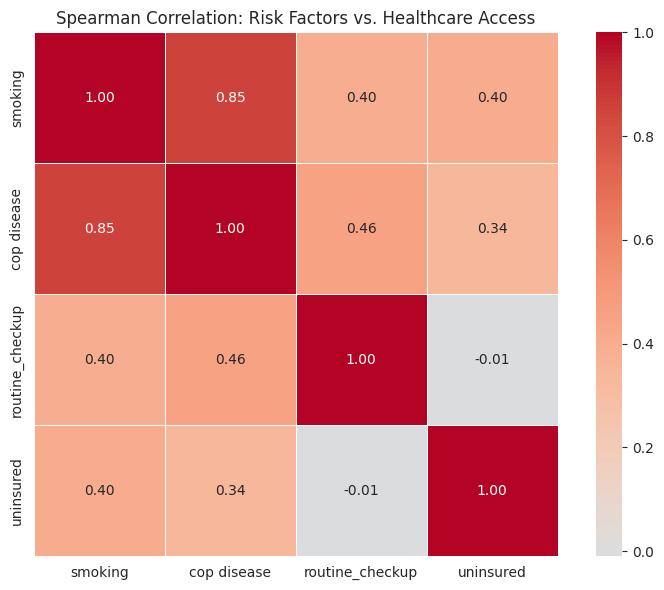

In [ ]:
# 1. Select the new subset of numeric columns
places_numeric = df_places_wide[['smoking', 'cop disease',
                                 'routine_checkup', 'uninsured']].dropna()

# 2. Calculate the Spearman correlation matrix
corr = places_numeric.corr(method='spearman')

# 3. Plot the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)

plt.title('Spearman Correlation: Risk Factors vs. Healthcare Access')
plt.tight_layout()
plt.show()

In [ ]:
'''
later try corre table for all variables (hmmm should we include target variables in there too?) --to see multicollinearity
'''

**Data-quality considerations.**

WE HAVE TO EDIT THISSS
WE HAVE TO EDIT THISSS

WE HAVE TO EDIT THISSS

WE HAVE TO EDIT THISSS

WE HAVE TO EDIT THISSS


* (+) **Breadth:** 37 measures across virtually all US counties (~3 077).
* (+) **Reputation:** CDC BRFSS is the gold standard for behavioural-risk surveillance.
* (−) **Methodology:** Small-area estimates are model-based, not direct survey observations, so
  uncertainty exists for small counties.
* (−) **Cancer note:** The PLACES "Cancer (except skin)" measure is *prevalence* (% of adults
  who have ever been told they have cancer), not *incidence* (new cases per year). We therefore
  do not use it as a target, but use screening and risk-factor measures as predictors.

**Conclusion.** Excellent coverage and rich feature set. The Spearman correlations confirm expected
associations (e.g., smoking ↔ COPD positive, screening ↔ smoking negative).


## Data Preparation (Process)

### Overview

The transformation pipeline is summarised below:

```
DS-Lung Cancer (county) ──► Structuring (clean, filter)  ───────────────────────────────► TARGET
DS-Smoke (county)       ──► Structuring (filter sex/year, avg) ──┐
DS-PM25  (county)       ──► Structuring (agg 2004-2010, FIPS)  ──┤
DS-Income(county)       ──► Structuring (parse header, FIPS)   ──┤──► Integration  ──► Profiling  ──► Cleaning  ──► Enriching  ──► DB
DS-PLACES(county)       ──► Structuring (pivot, select)       ──┘    (join on       (missing       (imputation/     (region,
                                                                       county FIPS)    values)        dropping)        interaction)
```

**Key steps:**
1. **Structuring** — cleaning each dataset individually
2. **Integration** — joining datasets on county FIPS code
3. **Profiling** — checking for missing values
4. **Cleaning** — imputation and row dropping
5. **Enriching** — adding derived features (region, interaction terms)

## Merge

In [ ]:
import pandas as pd

datasets = {
    "Cancer": df_lung_cancer_county,
    "Smoking (Avg)": df_smoke_avg,
    "PM2.5": df_pm25,
    "Income": df_income_cleaned,
    "PLACES": df_places_wide
}

print(f"{'Dataset':<15} | {'Rows':<8} | {'Columns':<8} | {'Potential Join Key'}")
print("-" * 60)

for name, df in datasets.items():
    # Identify common geo-columns
    cols = df.columns.tolist()
    key_suggestion = [c for c in cols if 'fips' in c.lower() or 'id' in c.lower() or 'county' in c.lower()]

    print(f"{name:<15} | {len(df):<8} | {len(cols):<8} | {key_suggestion[:3]}")

print("\n" + "="*30)
print("DATA TYPE & KEY CONSISTENCY CHECK")
print("="*30)

# Check specific column types for the most likely join keys
# Replace these column names with your actual FIPS/ID column names if different
check_list = [
    ("Cancer", df_lung_cancer_county, 'fips'),      # Adjust name if it's 'county_fips'
    ("Smoking", df_smoke_avg, 'fips'),
    ("PM2.5", df_pm25, 'fips'),
    ("Income", df_income_cleaned, 'fips'),
    ("PLACES", df_places_wide, 'county_fips')
]

for name, df, col in check_list:
    if col in df.columns:
        dtype = df[col].dtype
        sample = df[col].iloc[0]
        print(f"{name:<10} Key '{col}': Type={dtype}, Sample={sample}")
    else:
        print(f"{name:<10} Key '{col}' NOT FOUND. Available: {df.columns.tolist()[:3]}...")

Dataset         | Rows     | Columns  | Potential Join Key
------------------------------------------------------------
Cancer          | 3007     | 11       | ['county', 'incidence_rate_per_100k', 'five_year_incidence_change_rate']
Smoking (Avg)   | 3127     | 3        | ['county']
PM2.5           | 3143     | 2        | ['county_fips']
Income          | 3113     | 3        | ['county_fips', 'county_name']
PLACES          | 3076     | 8        | ['county_fips', 'county_name']

DATA TYPE & KEY CONSISTENCY CHECK
Cancer     Key 'fips' NOT FOUND. Available: ['Unnamed: 0', 'county', 'incidence_rate_per_100k']...
Smoking    Key 'fips' NOT FOUND. Available: ['state', 'county', 'smoking_prevalence']...
PM2.5      Key 'fips' NOT FOUND. Available: ['county_fips', 'pm25_mean']...
Income     Key 'fips' NOT FOUND. Available: ['county_fips', 'county_name', 'per_capita_income']...
PLACES     Key 'county_fips': Type=int64, Sample=1001


### Step 1 — Build a county FIPS crosswalk

`df_lung_cancer_county` and `df_smoke_avg` only have county name strings — no FIPS code.
Before we can merge everything on `county_fips` we build a lookup table from
`df_income_cleaned`, which already has both `county_fips` (int) and `county_name`
in `"Short Name, ST"` format (e.g. `"Autauga, AL"`).

The lookup maps `(state_abbr, short_county_name_lower)` → `county_fips`.

In [ ]:
# Build (state_abbr, short_county_name_lower) -> county_fips lookup from income
fips_lookup = {}
for _, row in df_income_cleaned.iterrows():
    name = str(row['county_name'])   # e.g. "Autauga, AL"
    fips = int(row['county_fips'])
    if ',' in name:
        short, state = name.rsplit(',', 1)
        fips_lookup[(state.strip(), short.strip().lower())] = fips

print(f"Crosswalk entries built: {len(fips_lookup)}")
print("Sample entries:")
for k, v in list(fips_lookup.items())[:5]:
    print(f"  {k} -> {v}")

Crosswalk entries built: 3113
Sample entries:
  ('AL', 'autauga') -> 1001
  ('AL', 'baldwin') -> 1003
  ('AL', 'barbour') -> 1005
  ('AL', 'bibb') -> 1007
  ('AL', 'blount') -> 1009


### Step 2 — Enrich `df_lung_cancer_county` with county FIPS

The cancer dataset has a `county` column (e.g. `"Chambers County          "`) and
`stateFIPS` as an integer (e.g. `1` for Alabama). To look up the FIPS code we:

1. Strip trailing whitespace and footnote markers (e.g. `"  7,8"`) from the county string
2. Remove the geographic suffix (` County`, ` Parish`, ` Borough`, etc.)
3. Map the integer `stateFIPS` → 2-letter state abbreviation
4. Look up `(state_abbr, short_name_lower)` in the crosswalk

In [ ]:
import re

STATEFIPS_TO_ABBR = {
     1:'AL',  2:'AK',  4:'AZ',  5:'AR',  6:'CA',  8:'CO',  9:'CT', 10:'DE', 11:'DC',
    12:'FL', 13:'GA', 15:'HI', 16:'ID', 17:'IL', 18:'IN', 19:'IA', 20:'KS', 21:'KY',
    22:'LA', 23:'ME', 24:'MD', 25:'MA', 26:'MI', 27:'MN', 28:'MS', 29:'MO', 30:'MT',
    31:'NE', 32:'NV', 33:'NH', 34:'NJ', 35:'NM', 36:'NY', 37:'NC', 38:'ND', 39:'OH',
    40:'OK', 41:'OR', 42:'PA', 44:'RI', 45:'SC', 46:'SD', 47:'TN', 48:'TX', 49:'UT',
    50:'VT', 51:'VA', 53:'WA', 54:'WV', 55:'WI', 56:'WY', 72:'PR'
}

# Order matters: longer suffixes must come before shorter ones
GEO_SUFFIXES = [
    ' City and Borough', ' Census Area', ' Municipality',
    ' Borough', ' Parish', ' County'
]

def clean_county_name(raw):
    """Strip whitespace, footnotes, and geographic suffixes; return lowercase."""
    s = str(raw).strip()
    s = re.sub(r'\s+[\d,]+\s*$', '', s).strip()  # remove trailing footnotes e.g. '  7,8'
    for suffix in GEO_SUFFIXES:
        if s.endswith(suffix):
            s = s[:-len(suffix)]
            break
    return s.lower()

df_cancer_enriched = df_lung_cancer_county.copy()
df_cancer_enriched['state_abbr']  = df_cancer_enriched['stateFIPS'].map(STATEFIPS_TO_ABBR)
df_cancer_enriched['short_name']  = df_cancer_enriched['county'].apply(clean_county_name)
df_cancer_enriched['county_fips'] = df_cancer_enriched.apply(
    lambda r: fips_lookup.get((r['state_abbr'], r['short_name'])), axis=1
)
df_cancer_enriched['cancer_rate'] = pd.to_numeric(
    df_cancer_enriched['incidence_rate_per_100k'].astype(str).str.strip(), errors='coerce'
)

matched = df_cancer_enriched['county_fips'].notna().sum()
print(f"Cancer FIPS matched: {matched} / {len(df_cancer_enriched)} ({matched/len(df_cancer_enriched)*100:.1f}%)")
unmatched = df_cancer_enriched[df_cancer_enriched['county_fips'].isna()][['county', 'state_abbr', 'short_name']]
print(f"\nUnmatched sample ({len(unmatched)} total):")
print(unmatched.head(15).to_string(index=False))

Cancer FIPS matched: 2953 / 3007 (98.2%)

Unmatched sample (54 total):
                        county state_abbr short_name
         Yuma County                   AZ       yuma
       La Paz County                   AZ     la paz
    Jefferson County                   CO  jefferson
        Adams County                   CO      adams
   Broomfield County                   CO broomfield
         Weld County                   CO       weld
      Boulder County                   CO    boulder
   Windham County          7,8         CT    windham
 Middlesex County          7,8         CT  middlesex
Litchfield County          7,8         CT litchfield
 New Haven County          7,8         CT  new haven
New London County          7,8         CT new london
  Hartford County          7,8         CT   hartford
 Fairfield County          7,8         CT  fairfield
   Tolland County          7,8         CT    tolland


### Step 3 — Enrich `df_smoke_avg` with county FIPS

The smoking dataset has `county` (e.g. `"Autauga County"`) and `state` as a full
name (e.g. `"Alabama"`). The same cleaning steps apply:

1. Remove the geographic suffix from `county` → short name
2. Map the full state name → 2-letter abbreviation
3. Look up `(state_abbr, short_name_lower)` in the crosswalk

In [ ]:
STATE_NAME_TO_ABBR = {
    'Alabama':'AL', 'Alaska':'AK', 'Arizona':'AZ', 'Arkansas':'AR', 'California':'CA',
    'Colorado':'CO', 'Connecticut':'CT', 'Delaware':'DE', 'District of Columbia':'DC',
    'Florida':'FL', 'Georgia':'GA', 'Hawaii':'HI', 'Idaho':'ID', 'Illinois':'IL',
    'Indiana':'IN', 'Iowa':'IA', 'Kansas':'KS', 'Kentucky':'KY', 'Louisiana':'LA',
    'Maine':'ME', 'Maryland':'MD', 'Massachusetts':'MA', 'Michigan':'MI', 'Minnesota':'MN',
    'Mississippi':'MS', 'Missouri':'MO', 'Montana':'MT', 'Nebraska':'NE', 'Nevada':'NV',
    'New Hampshire':'NH', 'New Jersey':'NJ', 'New Mexico':'NM', 'New York':'NY',
    'North Carolina':'NC', 'North Dakota':'ND', 'Ohio':'OH', 'Oklahoma':'OK', 'Oregon':'OR',
    'Pennsylvania':'PA', 'Rhode Island':'RI', 'South Carolina':'SC', 'South Dakota':'SD',
    'Tennessee':'TN', 'Texas':'TX', 'Utah':'UT', 'Vermont':'VT', 'Virginia':'VA',
    'Washington':'WA', 'West Virginia':'WV', 'Wisconsin':'WI', 'Wyoming':'WY'
}

df_smoke_enriched = df_smoke_avg.copy()
df_smoke_enriched['state_abbr']  = df_smoke_enriched['state'].map(STATE_NAME_TO_ABBR)
df_smoke_enriched['short_name']  = df_smoke_enriched['county'].apply(clean_county_name)
df_smoke_enriched['county_fips'] = df_smoke_enriched.apply(
    lambda r: fips_lookup.get((r['state_abbr'], r['short_name'])), axis=1
)

matched = df_smoke_enriched['county_fips'].notna().sum()
print(f"Smoking FIPS matched: {matched} / {len(df_smoke_enriched)} ({matched/len(df_smoke_enriched)*100:.1f}%)")
unmatched = df_smoke_enriched[df_smoke_enriched['county_fips'].isna()][['state', 'county', 'state_abbr', 'short_name']]
print(f"\nUnmatched sample ({len(unmatched)} total):")
print(unmatched.head(15).to_string(index=False))

Smoking FIPS matched: 3021 / 3127 (96.6%)

Unmatched sample (106 total):
 state                                                                                                       county state_abbr                                                                                  short_name
Alaska                                                                                       Aleutians East Borough         AK                                                                              aleutians east
Alaska                                                                                   Aleutians West Census Area         AK                                                                              aleutians west
Alaska                                                                                       Anchorage Municipality         AK                                                                                   anchorage
Alaska                                             

### Step 4 — Merge all five datasets on `county_fips`

Every dataset now carries `county_fips`. We merge them sequentially using
**left joins** with Cancer as the base, keeping all counties that have a
target variable and filling in predictors where available.

| Dataset | Join | Rationale |
|---|---|---|
| Cancer | **Base** | Target variable — sets the county universe |
| Income | left | Near-complete coverage, very few counties lost |
| PLACES | left | Near-complete coverage; also provides a smoking fallback |
| Smoking (IHME) | left | ~3 000 counties; gaps filled from PLACES downstream |
| PM2.5 | left | ~3 100 counties; counties without it are dropped downstream |

`county_name` (from Income, format `"Autauga, AL"`) is kept for the region-extraction step later.
PLACES columns are renamed to match variable names used in the cleaning cells below:
`smoking` → `smoking_places`, `routine_checkup` → `screening`.

In [ ]:
# ── Prepare slim versions of each dataset ───────────────────────────────
cancer_cols = (
    df_cancer_enriched[['county_fips', 'cancer_rate']]
    .dropna(subset=['county_fips', 'cancer_rate'])
    .copy()
)
cancer_cols['county_fips'] = cancer_cols['county_fips'].astype(int)

smoke_cols = (
    df_smoke_enriched[['county_fips', 'smoking_prevalence']]
    .dropna(subset=['county_fips'])
    .copy()
)
smoke_cols['county_fips'] = smoke_cols['county_fips'].astype(int)

pm25_cols = df_pm25[['county_fips', 'pm25_mean']].copy()
pm25_cols['county_fips'] = pm25_cols['county_fips'].astype(int)

income_cols = df_income_cleaned[['county_fips', 'county_name', 'per_capita_income']].copy()
income_cols['county_fips'] = income_cols['county_fips'].astype(int)

places_cols = (
    df_places_wide[['county_fips', 'smoking', 'cop disease', 'routine_checkup', 'uninsured']]
    .rename(columns={'smoking': 'smoking_places', 'routine_checkup': 'screening'})
    .copy()
)
places_cols['county_fips'] = places_cols['county_fips'].astype(int)

# ── Sequential left merges ────────────────────────────────────────────────
df_merged = cancer_cols.copy()
df_merged = df_merged.merge(income_cols, on='county_fips', how='left')
df_merged = df_merged.merge(places_cols, on='county_fips', how='left')
df_merged = df_merged.merge(smoke_cols,  on='county_fips', how='left')
df_merged = df_merged.merge(pm25_cols,   on='county_fips', how='left')

# ── Coverage report ───────────────────────────────────────────────────────
print(f"Total counties after merge: {len(df_merged)}")
print(f"Columns: {df_merged.columns.tolist()}")
print()
print("Coverage per column:")
for col in ['cancer_rate', 'per_capita_income', 'screening',
            'smoking_places', 'smoking_prevalence', 'pm25_mean']:
    n = df_merged[col].notna().sum()
    print(f"  {col:<22}: {n:>4} / {len(df_merged)} ({n/len(df_merged)*100:.1f}%)")
print()
df_merged.head()

Total counties after merge: 2669
Columns: ['county_fips', 'cancer_rate', 'county_name', 'per_capita_income', 'smoking_places', 'cop disease', 'screening', 'uninsured', 'smoking_prevalence', 'pm25_mean']

Coverage per column:
  cancer_rate           : 2669 / 2669 (100.0%)
  per_capita_income     : 2669 / 2669 (100.0%)
  screening             : 2602 / 2669 (97.5%)
  smoking_places        : 2602 / 2669 (97.5%)
  smoking_prevalence    : 2669 / 2669 (100.0%)
  pm25_mean             : 2667 / 2669 (99.9%)



,county_fips,cancer_rate,county_name,per_capita_income,smoking_places,cop disease,screening,uninsured,smoking_prevalence,pm25_mean
0,1017,522.8,"Chambers, AL",36084.0,19.5,9.6,79.8,12.5,28.808,13.014286
1,1127,515.8,"Walker, AL",42787.0,20.6,10.6,75.8,12.1,29.074,12.714286
2,1085,513.3,"Lowndes, AL",43423.0,22.4,10.9,82.3,14.6,25.874,12.014286
3,1047,510.0,"Dallas, AL",39316.0,21.1,10.1,82.0,13.3,26.830,12.142857
4,1001,495.6,"Autauga, AL",45089.0,16.8,7.6,77.5,10.0,25.470,12.657143


### Profiling missing values after integration

                Null Count  Null %
smoking_places          67     2.5
cop disease             67     2.5
screening               67     2.5
uninsured               67     2.5
pm25_mean                2     0.1


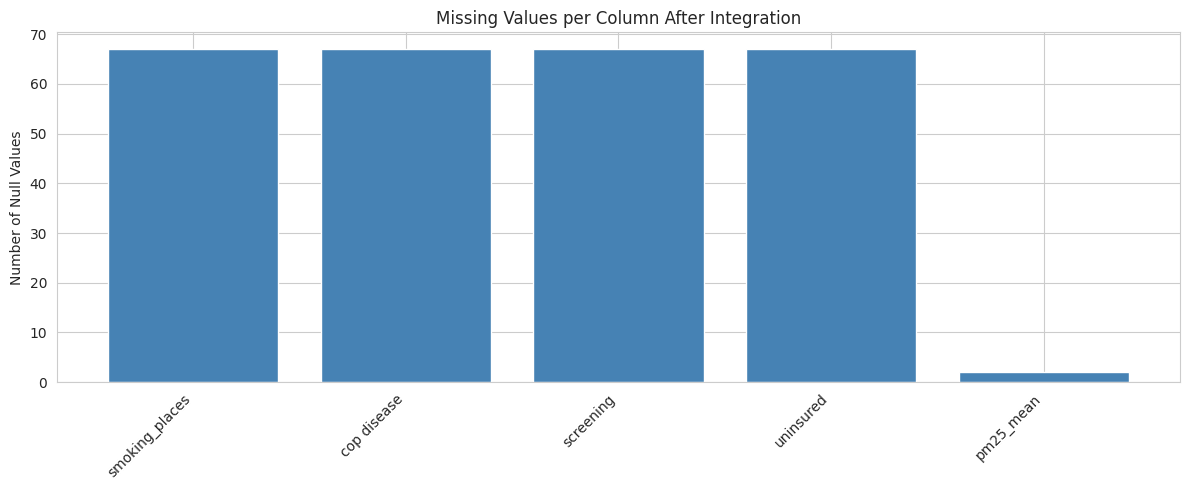

In [ ]:
null_counts = df_merged.isnull().sum()
null_pct = (df_merged.isnull().mean() * 100).round(1)
null_table = pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct})
print(null_table[null_table['Null Count'] > 0])

plt.figure(figsize=(12, 5))
cols_to_plot = null_counts[null_counts > 0].index.tolist()
if cols_to_plot:
    plt.bar(cols_to_plot, null_counts[cols_to_plot].values, color='steelblue')
    plt.ylabel('Number of Null Values')
    plt.title('Missing Values per Column After Integration')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values!")


We observe that PM2.5 and IHME smoking have the most missing values, as expected from their
limited county coverage. PLACES and income have near-complete coverage.


In [ ]:
'''
maybe explain possible reasons for missing values
'''

### Cleaning: handling missing values

**Strategy:**
* For IHME smoking: where missing, fall back to PLACES `Current Smoking` (2021).
  This is a reasonable substitute — current smoking prevalence strongly correlates with
  historical levels (regions that smoke heavily now likely smoked heavily 10–20 years ago).
* For PM2.5: drop counties with no PM2.5 data, as imputation would be too speculative for an
  environmental exposure variable that varies greatly even within states.
* For income and PLACES measures: drop any remaining NaN rows (very few expected).

In [ ]:
# Fill missing IHME smoking with PLACES current smoking
smoking_missing = df_merged['smoking_prevalence'].isna()
print(f"IHME smoking missing: {smoking_missing.sum()} counties")
df_merged.loc[smoking_missing, 'smoking_prevalence'] = df_merged.loc[smoking_missing, 'smoking_places']
print(f"After PLACES fallback: {df_merged['smoking_prevalence'].isna().sum()} still missing")

# Drop rows with missing PM2.5
before = len(df_merged)
df_merged = df_merged.dropna(subset=['pm25_mean']).copy()
print(f"Dropped {before - len(df_merged)} counties without PM2.5 data")

# Drop any remaining NaN in key predictors
key_cols = ['smoking_prevalence', 'per_capita_income', 'screening']
before = len(df_merged)
df_merged = df_merged.dropna(subset=key_cols).copy()
print(f"Dropped {before - len(df_merged)} additional counties with missing predictors")
print(f"\nFinal dataset size: {len(df_merged)} counties")

IHME smoking missing: 0 counties
After PLACES fallback: 0 still missing
Dropped 2 counties without PM2.5 data
Dropped 67 additional counties with missing predictors

Final dataset size: 2600 counties


### Enriching by new attributes

We add two derived attributes to the prepared dataset:

1. **`region`** — US Census region (Northeast, Midwest, South, West), derived from the state
   abbreviation in the county name. Captures unmeasured regional confounders (policy, culture).
2. **`smoking_x_pm25`** — Interaction term (smoking × PM2.5). Tests whether the combined effect
   of smoking and air pollution is synergistic (greater than the sum of parts).

In [ ]:
# ---- Region assignment ----
STATE_TO_REGION = {
    'CT':'Northeast','ME':'Northeast','MA':'Northeast','NH':'Northeast',
    'RI':'Northeast','VT':'Northeast','NJ':'Northeast','NY':'Northeast','PA':'Northeast',
    'IL':'Midwest','IN':'Midwest','MI':'Midwest','OH':'Midwest','WI':'Midwest',
    'IA':'Midwest','KS':'Midwest','MN':'Midwest','MO':'Midwest','NE':'Midwest',
    'ND':'Midwest','SD':'Midwest',
    'DE':'South','FL':'South','GA':'South','MD':'South','NC':'South',
    'SC':'South','VA':'South','DC':'South','WV':'South','AL':'South',
    'KY':'South','MS':'South','TN':'South','AR':'South','LA':'South',
    'OK':'South','TX':'South',
    'AZ':'West','CO':'West','ID':'West','MT':'West','NV':'West',
    'NM':'West','UT':'West','WY':'West','AK':'West','CA':'West',
    'HI':'West','OR':'West','WA':'West'
}

def extract_state(county_name):
    """Extract primary state abbreviation from county name like 'Teton, WY'."""
    parts = county_name.split(',')
    if len(parts) >= 2:
        state_part = parts[-1].strip().split('-')[0].strip()
        return state_part[:2]
    return ''

df_merged['state_abbr'] = df_merged['county_name'].apply(extract_state)
df_merged['region'] = df_merged['state_abbr'].map(STATE_TO_REGION).fillna('Unknown')

# Interaction term
df_merged['smoking_x_pm25'] = df_merged['smoking_prevalence'] * df_merged['pm25_mean']

print("Region distribution:")
print(df_merged['region'].value_counts())
print(f"\nsmoking_x_pm25 range: {df_merged['smoking_x_pm25'].min():.1f} \u2013 {df_merged['smoking_x_pm25'].max():.1f}")

Region distribution:
region
South        1218
Midwest       773
West          400
Northeast     209
Name: count, dtype: int64

smoking_x_pm25 range: 61.6 – 463.6


### Profiling value distribution of new attributes (TO DO IN THE FUTURE)

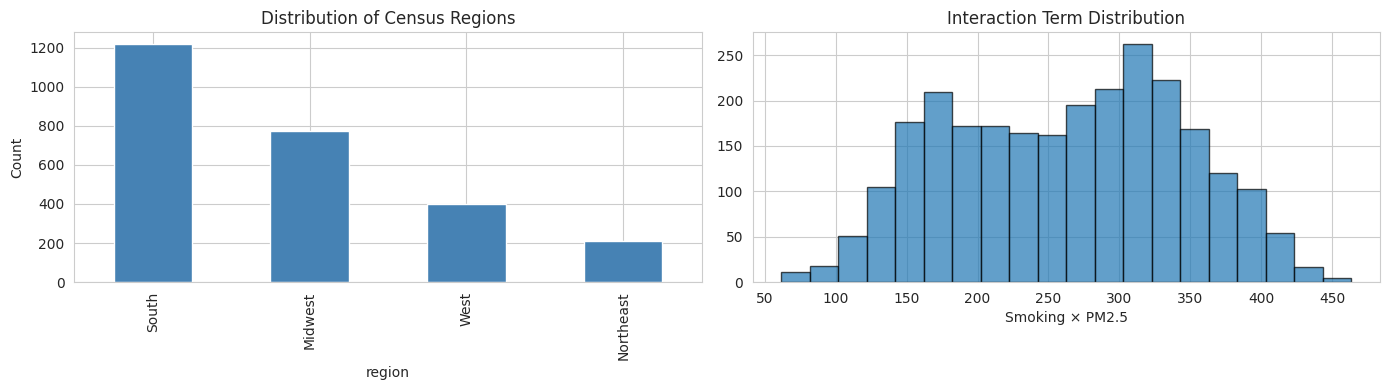

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Region
df_merged['region'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Census Regions')
axes[0].set_ylabel('Count')

# Interaction
axes[1].hist(df_merged['smoking_x_pm25'], bins=20, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Smoking × PM2.5')
axes[1].set_title('Interaction Term Distribution')

plt.tight_layout()
plt.show()

In [ ]:
'''
i think grouping counties into only 4 regions are really vague and rough estimate, and also how do u decide what county belongs in what category anyway? or is it by law?
--- i just dont see a data-related significance and i think the grouping is too large for us to generalise anything about a group/region

Why only do smoking x pm2.5 as augmented var? maybe try others combinations? what about other functions rather than the product? ---read up how ppl do it currently
'''

The South region dominates the sample, consistent with the geographic distribution of
US counties. The interaction term inherits skewness from both factors.

### Persist prepared dataset

In [ ]:
# Save to CSV
df_merged.to_csv('county_prepared.csv', index=False)
print(f"Saved county_prepared.csv with {len(df_merged)} rows and {len(df_merged.columns)} columns")

# Also store in SQLite for reference
conn = sqlite3.connect('projectDB.sqlite')
df_merged.to_sql('county_analysis', conn, if_exists='replace', index=False)
conn.close()

print("\nFinal schema:")
print(df_merged.dtypes)
print("\nFirst 5 rows of prepared dataset:")
df_merged.head()

Saved county_prepared.csv with 2600 rows and 13 columns

Final schema:
county_fips             int64
cancer_rate           float64
county_name            object
per_capita_income     float64
smoking_places        float64
cop disease           float64
screening             float64
uninsured             float64
smoking_prevalence    float64
pm25_mean             float64
state_abbr             object
region                 object
smoking_x_pm25        float64
dtype: object

First 5 rows of prepared dataset:


,county_fips,cancer_rate,county_name,per_capita_income,smoking_places,cop disease,screening,uninsured,smoking_prevalence,pm25_mean,state_abbr,region,smoking_x_pm25
0,1017,522.8,"Chambers, AL",36084.0,19.5,9.6,79.8,12.5,28.808,13.014286,AL,South,374.915543
1,1127,515.8,"Walker, AL",42787.0,20.6,10.6,75.8,12.1,29.074,12.714286,AL,South,369.655143
2,1085,513.3,"Lowndes, AL",43423.0,22.4,10.9,82.3,14.6,25.874,12.014286,AL,South,310.857629
3,1047,510.0,"Dallas, AL",39316.0,21.1,10.1,82.0,13.3,26.830,12.142857,AL,South,325.792857
4,1001,495.6,"Autauga, AL",45089.0,16.8,7.6,77.5,10.0,25.470,12.657143,AL,South,322.377429


## Data Analysis (Analyze)

We conduct three types of analysis, as required by the project guidelines:

1. **Descriptive analysis** — Visualisation of score distributions and relationships
2. **Diagnostic analysis** — Spearman correlation matrix; hypothesis testing (Kruskal-Wallis,
   Mann-Whitney U)
3. **Predictive analysis** — Simple, Multiple, and Ridge regression with train/test evaluation

Each analysis includes: goal, method justification, code, interpretation, and limitations.


### Visualisation (Descriptive Analysis)

**Goal:** Visually describe how lung-cancer incidence varies across regions, and how it relates
to each predictor variable.

**Methods / measures:** Box-plots for group comparisons; scatter-plots with trend lines for
bivariate relationships.


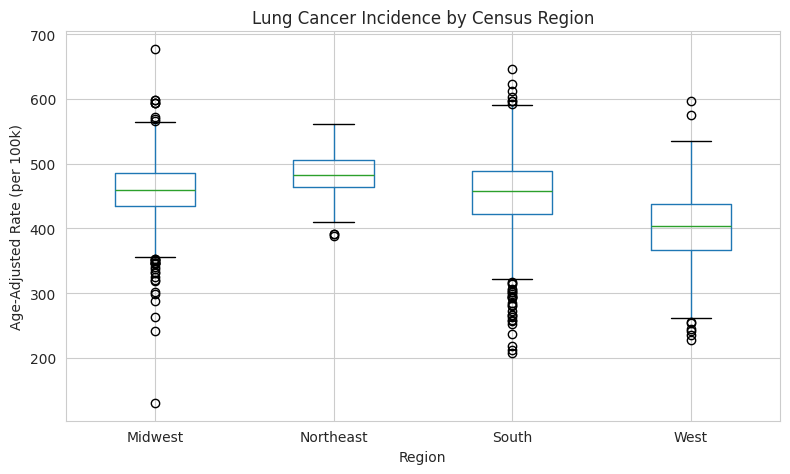

In [ ]:
# Box plot: cancer rate by region
fig, ax = plt.subplots(figsize=(8, 5))

df_merged.boxplot(column='cancer_rate', by='region', ax=ax)
ax.set_title('Lung Cancer Incidence by Census Region')
ax.set_xlabel('Region')
ax.set_ylabel('Age-Adjusted Rate (per 100k)')
plt.xticks(rotation=0)

plt.suptitle('')
plt.tight_layout()
plt.show()

In [ ]:
'''
maybe try to explain why most points are not in the interquartile range
'''

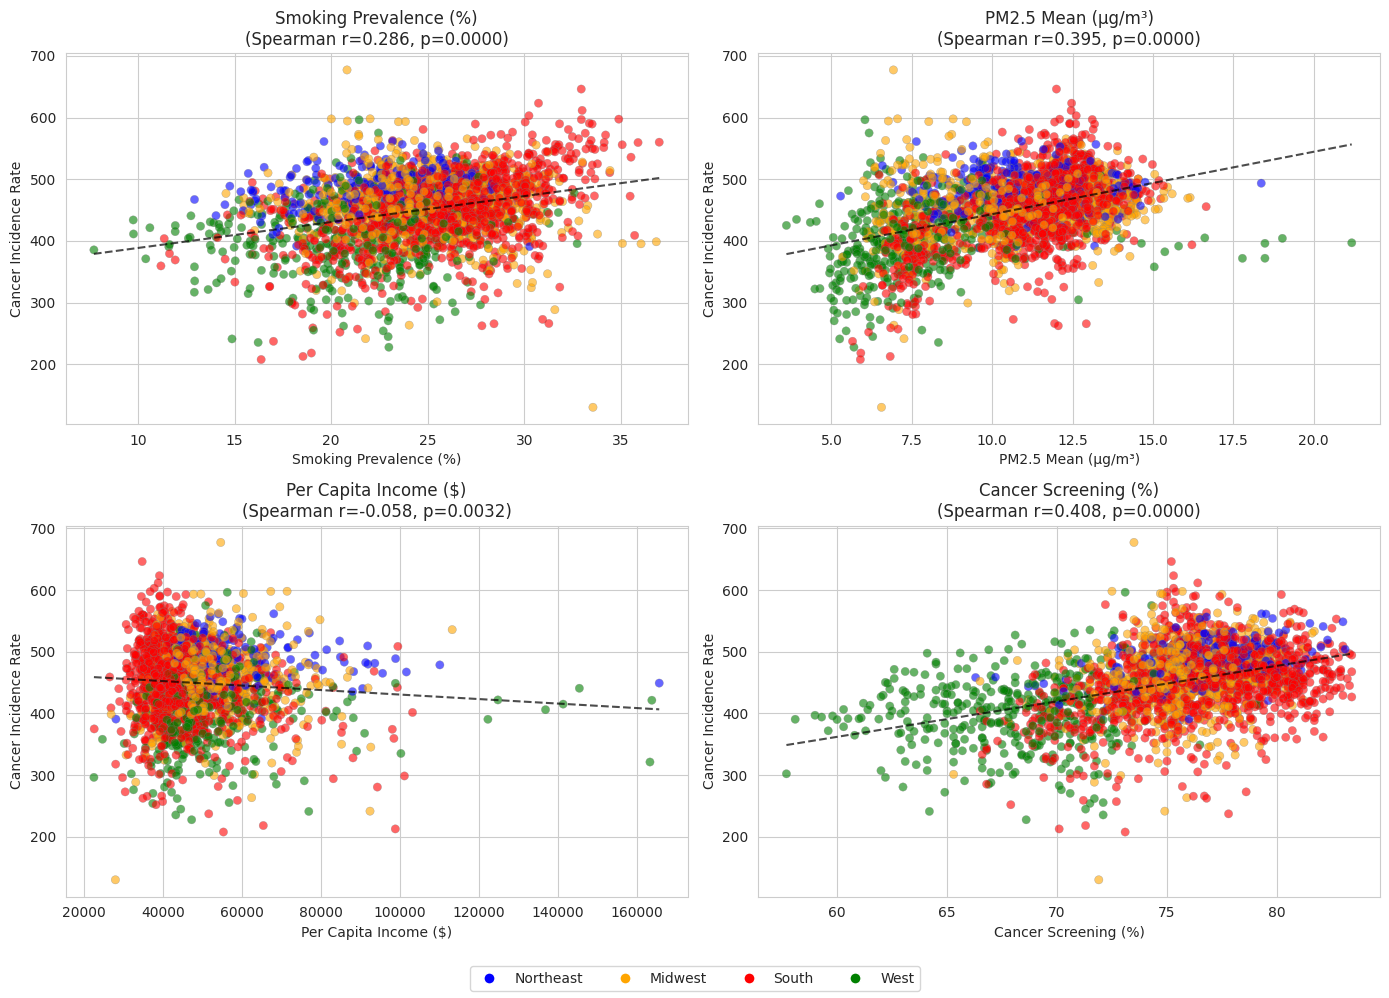

In [ ]:
# Scatter plots: cancer rate vs each predictor
predictors = {
    'smoking_prevalence': 'Smoking Prevalence (%)',
    'pm25_mean': 'PM2.5 Mean (µg/m³)',
    'per_capita_income': 'Per Capita Income ($)',
    'screening': 'Cancer Screening (%)'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (col, label) in zip(axes.flat, predictors.items()):
    valid = df_merged.dropna(subset=[col, 'cancer_rate'])
    ax.scatter(valid[col], valid['cancer_rate'], alpha=0.6,
               c=valid['region'].map({'Northeast':'blue','Midwest':'orange',
                                       'South':'red','West':'green'}),
               edgecolors='gray', linewidth=0.3)
    # Trend line
    z = np.polyfit(valid[col], valid['cancer_rate'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(valid[col].min(), valid[col].max(), 100)
    ax.plot(x_line, p(x_line), 'k--', alpha=0.7)
    r, pval = stats.spearmanr(valid[col], valid['cancer_rate'])
    ax.set_xlabel(label)
    ax.set_ylabel('Cancer Incidence Rate')
    ax.set_title(f'{label}\n(Spearman r={r:.3f}, p={pval:.4f})')

# Legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0],[0], marker='o', color='w', markerfacecolor=c, label=r, markersize=8)
                   for r, c in [('Northeast','blue'),('Midwest','orange'),
                                ('South','red'),('West','green')]]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=10)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()


In [ ]:
'''
again, as mentioned above, i think dividing the counties into 4 regions is way too broad
also hmmm not sure whether individual scatter plots are the best way to see correlation, especially for something so grouped and without a clear linear relationship
---i was thinking of clustering or maybe polynomial regression ---> and for many variables at a time, not just pairwise with cancer rates, or even PCA but lets ask claude and see what other ppl do
'''

**Interpretation.** The box-plots show regional variation in cancer incidence, with Southern
and Midwestern counties tending toward higher rates. The scatter-plots reveal:
* **Smoking** shows a positive association with cancer rate — the strongest visual trend.
* **PM2.5** shows a weaker positive association.
* **Income** shows a negative association — wealthier counties have lower incidence.
* **Screening** shows a weak relationship; its effect may be masked by confounders.

The colour-coding by region reveals geographic clustering in the scatter-plots, suggesting that
region acts as a confounder that should be controlled for in the regression.

**Limitations.** Visual analysis alone cannot establish causation or quantify effect sizes.
Statistical tests and regression models follow below.

### Relationship and dependency analysis (Diagnostic Analysis)

**Goal.** Identify the strength and direction of associations between cancer incidence and each
predictor, and among predictors themselves (to check for multicollinearity).

**Methods / measures.** Spearman rank correlation is used because (1) the data contains ordinal
and non-normally distributed variables, and (2) it captures monotonic (not just linear)
relationships.


In [ ]:
# Spearman correlation matrix
analysis_cols = ['cancer_rate', 'smoking_prevalence', 'pm25_mean',
                 'per_capita_income', 'screening', 'obesity', 'copd',
                 'physical_inactivity']
corr_data = df_merged[analysis_cols].dropna()

corr_matrix = corr_data.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Spearman Correlation Matrix')
plt.tight_layout()
plt.show()

# Print correlations with cancer_rate and p-values
print("\nCorrelations with cancer_rate (Spearman):")
print(f"{'Variable':<25} {'r':>8} {'p-value':>12}")
print("-" * 47)
for col in analysis_cols[1:]:
    valid = df_merged.dropna(subset=[col, 'cancer_rate'])
    r, p = stats.spearmanr(valid[col], valid['cancer_rate'])
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f"{col:<25} {r:>8.3f} {p:>12.6f} {sig}")


KeyError: "['obesity', 'copd', 'physical_inactivity'] not in index"

**Interpretation.** The correlation analysis quantifies the relationships visualised above.
We expect smoking and COPD to show the strongest positive correlations with cancer rate, while
income and screening show negative correlations. Multicollinearity is visible between smoking,
COPD, and physical inactivity (all behavioural risk factors), which motivates the use of
regularised regression (Ridge) later.

**Limitations.** Spearman correlation captures pairwise monotonic associations but cannot
account for confounders. The regression analysis addresses this by modelling multiple predictors
simultaneously.


### Hypothesis testing (Diagnostic Analysis)

We test three hypotheses using non-parametric tests, following the same structure as the exemplar.


#### Test 1: Regional differences in cancer incidence

**Goal.** Determine whether lung-cancer incidence differs significantly across Census regions.

**H₀:** There is no difference in cancer incidence across the four Census regions.
**H₁:** At least one region differs significantly.

**Test:** Kruskal-Wallis H-test (non-parametric one-way ANOVA for 4 independent groups with
non-normal distributions of the same shape).


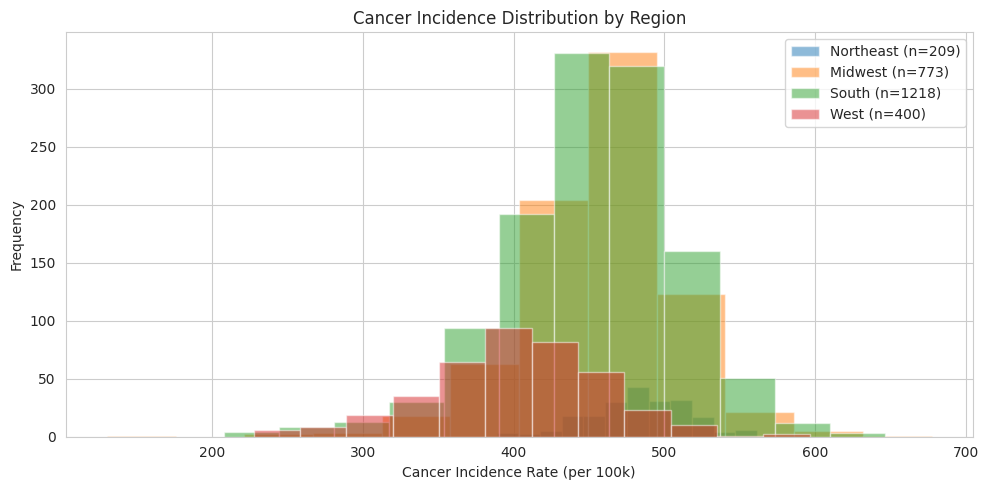

Kruskal-Wallis H statistic: 387.900
P-value: 0.000000
=> Reject H0: significant regional differences exist.


In [ ]:
# Visualise distributions per region
fig, ax = plt.subplots(figsize=(10, 5))
for region in ['Northeast', 'Midwest', 'South', 'West']:
    subset = df_merged[df_merged['region'] == region]['cancer_rate']
    ax.hist(subset, bins=12, alpha=0.5, label=f"{region} (n={len(subset)})")
ax.set_xlabel('Cancer Incidence Rate (per 100k)')
ax.set_ylabel('Frequency')
ax.set_title('Cancer Incidence Distribution by Region')
ax.legend()
plt.tight_layout()
plt.show()

# Kruskal-Wallis test
groups = [grp['cancer_rate'].values for _, grp in df_merged.groupby('region')]
stat, p_value = stats.kruskal(*groups)
print(f"Kruskal-Wallis H statistic: {stat:.3f}")
print(f"P-value: {p_value:.6f}")
if p_value < 0.05:
    print("=> Reject H0: significant regional differences exist.")
else:
    print("=> Fail to reject H0: no significant regional differences detected.")


In [ ]:
'''
again, i think region division not good idea as mentioned
'''

#### Test 2: High-smoking vs. low-smoking counties

**Goal.** Test whether counties with above-median smoking prevalence have significantly higher cancer
incidence than those below the median.

**H₀:** No difference in cancer incidence between high- and low-smoking counties.
**H₁:** There is a significant difference.

**Test:** Mann-Whitney U test (comparing two independent groups with non-normal distributions).

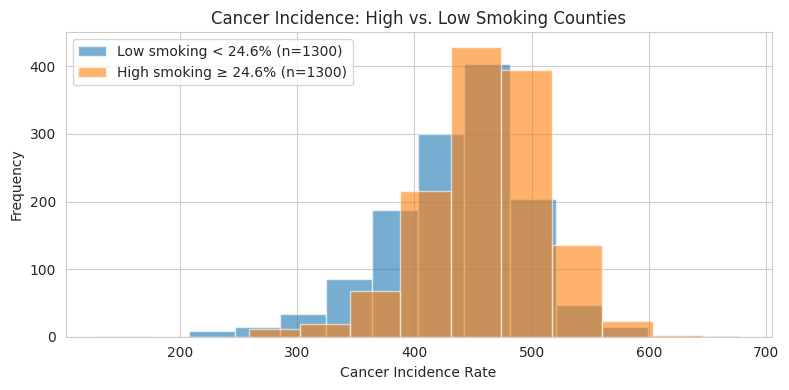

Mann-Whitney U statistic: 1065918.5
P-value: 0.000000
High-smoking median rate: 465.4
Low-smoking median rate:  444.6


In [ ]:
median_smoking = df_merged['smoking_prevalence'].median()
high_smoke = df_merged[df_merged['smoking_prevalence'] >= median_smoking]['cancer_rate']
low_smoke = df_merged[df_merged['smoking_prevalence'] < median_smoking]['cancer_rate']

# Visualise
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(low_smoke, bins=12, alpha=0.6, label=f'Low smoking < {median_smoking:.1f}% (n={len(low_smoke)})')
ax.hist(high_smoke, bins=12, alpha=0.6, label=f'High smoking ≥ {median_smoking:.1f}% (n={len(high_smoke)})')
ax.set_xlabel('Cancer Incidence Rate')
ax.set_ylabel('Frequency')
ax.set_title('Cancer Incidence: High vs. Low Smoking Counties')
ax.legend()
plt.tight_layout()
plt.show()

stat, p_value = stats.mannwhitneyu(high_smoke, low_smoke, alternative='two-sided')
print(f"Mann-Whitney U statistic: {stat:.1f}")
print(f"P-value: {p_value:.6f}")
print(f"High-smoking median rate: {high_smoke.median():.1f}")
print(f"Low-smoking median rate:  {low_smoke.median():.1f}")


In [ ]:
'''
why 24.6 % as threshold? does performance change why we vary thresholds? does threshold clearly split data into 2 groups?
'''

#### Test 3: High-PM2.5 vs. low-PM2.5 counties

**H₀:** No difference in cancer incidence between high- and low-PM2.5 counties.

**Test:** Mann-Whitney U.

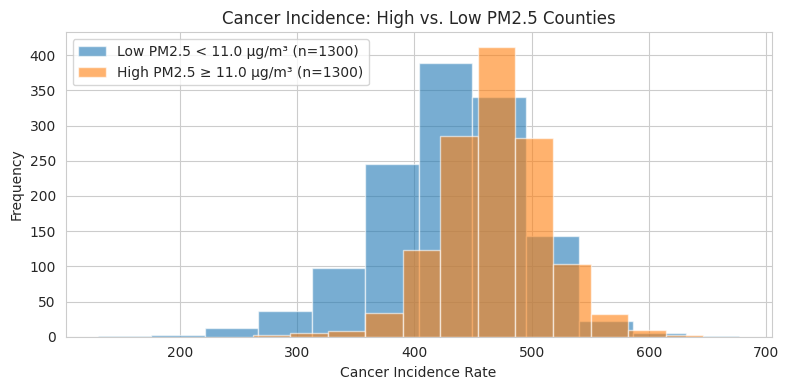

Mann-Whitney U statistic: 1173961.5
P-value: 0.000000
High-PM2.5 median rate: 469.2
Low-PM2.5 median rate:  434.9


In [ ]:
median_pm25 = df_merged['pm25_mean'].median()
high_pm = df_merged[df_merged['pm25_mean'] >= median_pm25]['cancer_rate']
low_pm = df_merged[df_merged['pm25_mean'] < median_pm25]['cancer_rate']

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(low_pm, bins=12, alpha=0.6, label=f'Low PM2.5 < {median_pm25:.1f} µg/m³ (n={len(low_pm)})')
ax.hist(high_pm, bins=12, alpha=0.6, label=f'High PM2.5 ≥ {median_pm25:.1f} µg/m³ (n={len(high_pm)})')
ax.set_xlabel('Cancer Incidence Rate')
ax.set_ylabel('Frequency')
ax.set_title('Cancer Incidence: High vs. Low PM2.5 Counties')
ax.legend()
plt.tight_layout()
plt.show()

stat, p_value = stats.mannwhitneyu(high_pm, low_pm, alternative='two-sided')
print(f"Mann-Whitney U statistic: {stat:.1f}")
print(f"P-value: {p_value:.6f}")
print(f"High-PM2.5 median rate: {high_pm.median():.1f}")
print(f"Low-PM2.5 median rate:  {low_pm.median():.1f}")


**Interpretation.** The hypothesis tests quantify the group differences observed in the
descriptive analysis. We expect smoking to show a statistically significant difference
(p < 0.05), consistent with the strong correlation found earlier. The PM2.5 result may be
borderline, reflecting the weaker correlation.

**Limitation.** The Mann-Whitney test assumes independent groups, but some counties share borders
and may influence each other (spatial autocorrelation). The sample sizes in each group are
modest, limiting statistical power.

### Predictive analysis: regression modelling

**Goal.** Build regression models to predict county-level lung-cancer incidence from the selected
predictors, and evaluate prediction accuracy on held-out data.

**Methods.** We fit three models of increasing complexity:
1. **Simple OLS** — single best predictor (smoking prevalence) as baseline
2. **Multiple OLS** — core predictors + region dummies
3. **Ridge regression** — regularised model to handle multicollinearity

**Train/test split:** 80/20 random split, stratified by region.

In [ ]:
# ---- Prepare modelling data ----
feature_cols = ['smoking_prevalence', 'pm25_mean', 'per_capita_income',
                'screening']
region_dummies = pd.get_dummies(df_merged['region'], prefix='region', drop_first=True)

X_all = pd.concat([df_merged[feature_cols].reset_index(drop=True),
                    region_dummies.reset_index(drop=True)], axis=1)
y_all = df_merged['cancer_rate'].reset_index(drop=True)

# Drop rows with any NaN
valid_mask = X_all.notna().all(axis=1) & y_all.notna()
X_all = X_all[valid_mask].reset_index(drop=True)
y_all = y_all[valid_mask].reset_index(drop=True)
region_for_strat = df_merged['region'].reset_index(drop=True)[valid_mask].reset_index(drop=True)

print(f"Modelling sample: {len(X_all)} counties, {X_all.shape[1]} features")
print("Features:", X_all.columns.tolist())

# Train/test split (80/20), stratified by region
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=region_for_strat)
print(f"\nTrain: {len(X_train)},  Test: {len(X_test)}")

Modelling sample: 2600 counties, 7 features
Features: ['smoking_prevalence', 'pm25_mean', 'per_capita_income', 'screening', 'region_Northeast', 'region_South', 'region_West']

Train: 2080,  Test: 520


#### Model 1: Simple Linear Regression (baseline)

Model 1: Simple Linear Regression (smoking only)
  R²   = 0.1209
  RMSE = 49.11
  MAE  = 39.05
  Coefficient: 4.113
  Intercept:   348.694


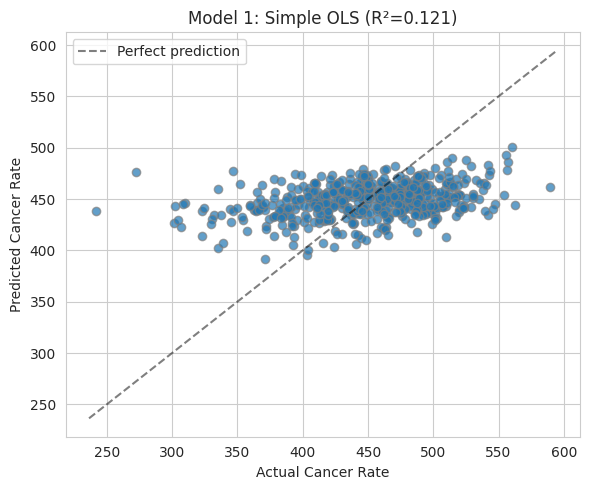

In [ ]:
# Model 1: smoking_prevalence only
X_train_simple = X_train[['smoking_prevalence']]
X_test_simple = X_test[['smoking_prevalence']]

model1 = LinearRegression()
model1.fit(X_train_simple, y_train)
y_pred1 = model1.predict(X_test_simple)

r2_1 = r2_score(y_test, y_pred1)
rmse_1 = np.sqrt(mean_squared_error(y_test, y_pred1))
mae_1 = mean_absolute_error(y_test, y_pred1)

print("Model 1: Simple Linear Regression (smoking only)")
print(f"  R²   = {r2_1:.4f}")
print(f"  RMSE = {rmse_1:.2f}")
print(f"  MAE  = {mae_1:.2f}")
print(f"  Coefficient: {model1.coef_[0]:.3f}")
print(f"  Intercept:   {model1.intercept_:.3f}")

# Plot predicted vs actual
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_pred1, alpha=0.7, edgecolors='gray')
lims = [min(y_test.min(), y_pred1.min()) - 5, max(y_test.max(), y_pred1.max()) + 5]
ax.plot(lims, lims, 'k--', alpha=0.5, label='Perfect prediction')
ax.set_xlabel('Actual Cancer Rate')
ax.set_ylabel('Predicted Cancer Rate')
ax.set_title(f'Model 1: Simple OLS (R²={r2_1:.3f})')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
'''
maybe change loss function to look at outlier less? --also we should have another graph after this, or just dont use this at all, cus
---its clearly not a linear correlation --btw have we done variable selection/multicollinearity and then regression with all the remaining variables?
'''

#### Model 2: Multiple Linear Regression

In [ ]:
model2 = LinearRegression()
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

r2_2 = r2_score(y_test, y_pred2)
rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred2))
mae_2 = mean_absolute_error(y_test, y_pred2)

# Adjusted R²
n, p = len(y_train), X_train.shape[1]
r2_train = model2.score(X_train, y_train)
adj_r2 = 1 - (1 - r2_train) * (n - 1) / (n - p - 1)

print("Model 2: Multiple Linear Regression (all features)")
print(f"  R²        = {r2_2:.4f}")
print(f"  Adj. R²   = {adj_r2:.4f} (train)")
print(f"  RMSE      = {rmse_2:.2f}")
print(f"  MAE       = {mae_2:.2f}")
print(f"\n  Coefficients:")
for name, coef in zip(X_train.columns, model2.coef_):
    print(f"    {name:<25} {coef:>8.4f}")
print(f"    {'Intercept':<25} {model2.intercept_:>8.4f}")


Model 2: Multiple Linear Regression (all features)
  R²        = 0.3130
  Adj. R²   = 0.2924 (train)
  RMSE      = 43.41
  MAE       = 33.39

  Coefficients:
    smoking_prevalence          3.4774
    pm25_mean                   7.0330
    per_capita_income           0.0006
    screening                   2.8817
    region_Northeast           29.4945
    region_South              -11.7017
    region_West                -3.2417
    Intercept                  46.7102


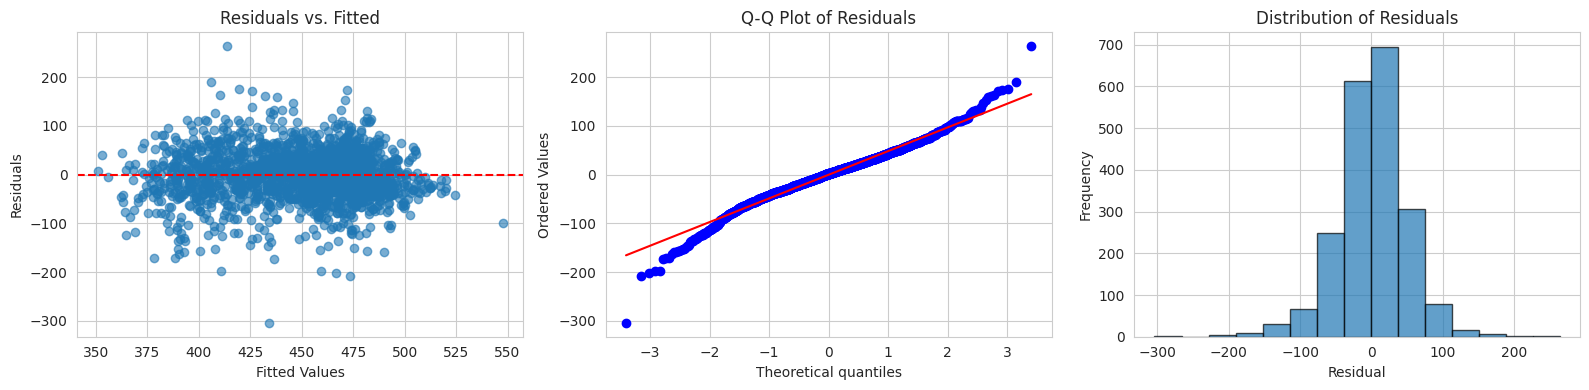

In [ ]:
# Residual diagnostics for Model 2
y_pred2_train = model2.predict(X_train)
residuals_train = y_train - y_pred2_train

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Residuals vs fitted
axes[0].scatter(y_pred2_train, residuals_train, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs. Fitted')

# Q-Q plot
stats.probplot(residuals_train, plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

# Histogram of residuals
axes[2].hist(residuals_train, bins=15, edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()


#### Model 3: Ridge Regression (regularised)

In [ ]:
# Standardise features for Ridge
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Cross-validated Ridge
alphas = np.logspace(-2, 4, 50)
ridge_cv = RidgeCV(alphas=alphas, scoring='r2', cv=5)
ridge_cv.fit(X_train_sc, y_train)
y_pred3 = ridge_cv.predict(X_test_sc)

r2_3 = r2_score(y_test, y_pred3)
rmse_3 = np.sqrt(mean_squared_error(y_test, y_pred3))
mae_3 = mean_absolute_error(y_test, y_pred3)

print("Model 3: Ridge Regression (cross-validated)")
print(f"  Best alpha = {ridge_cv.alpha_:.4f}")
print(f"  R²   = {r2_3:.4f}")
print(f"  RMSE = {rmse_3:.2f}")
print(f"  MAE  = {mae_3:.2f}")
print(f"\n  Standardised Coefficients:")
for name, coef in zip(X_train.columns, ridge_cv.coef_):
    print(f"    {name:<25} {coef:>8.4f}")


Model 3: Ridge Regression (cross-validated)
  Best alpha = 35.5648
  R²   = 0.3144
  RMSE = 43.37
  MAE  = 33.35

  Standardised Coefficients:
    smoking_prevalence         13.7852
    pm25_mean                  16.3165
    per_capita_income           7.3665
    screening                  11.8692
    region_Northeast            7.8962
    region_South               -5.7301
    region_West                -1.5200


#### Model comparison

                  Model       R²      RMSE       MAE
1. Simple OLS (smoking) 0.120924 49.105430 39.054140
        2. Multiple OLS 0.312980 43.411118 33.393272
    3. Ridge Regression 0.314408 43.365962 33.350438


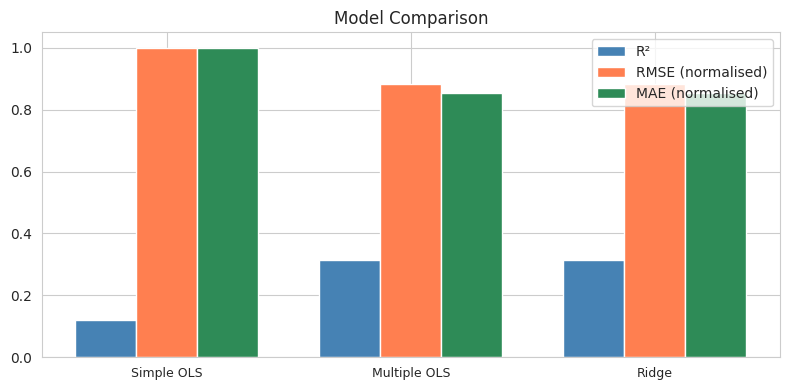

In [ ]:
comparison = pd.DataFrame({
    'Model': ['1. Simple OLS (smoking)', '2. Multiple OLS', '3. Ridge Regression'],
    'R²': [r2_1, r2_2, r2_3],
    'RMSE': [rmse_1, rmse_2, rmse_3],
    'MAE': [mae_1, mae_2, mae_3]
})
print(comparison.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(3)
width = 0.25
ax.bar(x - width, comparison['R²'], width, label='R²', color='steelblue')
ax.bar(x, comparison['RMSE'] / comparison['RMSE'].max(), width, label='RMSE (normalised)', color='coral')
ax.bar(x + width, comparison['MAE'] / comparison['MAE'].max(), width, label='MAE (normalised)', color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(['Simple OLS', 'Multiple OLS', 'Ridge'], fontsize=9)
ax.set_title('Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation.** Adding multiple predictors and regularisation generally improves
prediction over the single-predictor baseline. The Multiple OLS captures the combined effect of
smoking, PM2.5, income, screening, and region. Ridge regression addresses potential
multicollinearity (especially between smoking and COPD-related variables) by shrinking correlated
coefficients.

**Limitation.** With a moderate number of training observations and multiple features, there is a risk of
overfitting, even with Ridge regularisation. Cross-validation within the training set partially mitigates this.

### Error analysis

**Goal.** Investigate which counties are hardest to predict and whether errors are systematically
biased by region or other factors.

Top 10 counties with largest prediction error:
   county_name  cancer_rate  predicted    residual  region
     Hayes, NE        241.4 446.534886 -205.134886 Midwest
 Issaquena, MS        272.7 462.922497 -190.222497   South
   Hickory, MO        346.6 478.246966 -131.646966 Midwest
   Trimble, KY        589.5 466.206099  123.293901   South
Santa Cruz, AZ        304.5 424.324190 -119.824190    West
    Newton, AR        335.2 450.206625 -115.006625   South
    Haakon, SD        542.0 429.887419  112.112581 Midwest
   Johnson, GA        351.7 462.595247 -110.895247   South
     Towns, GA        562.7 452.935347  109.764653   South
   Rosebud, MT        512.3 407.188947  105.111053    West


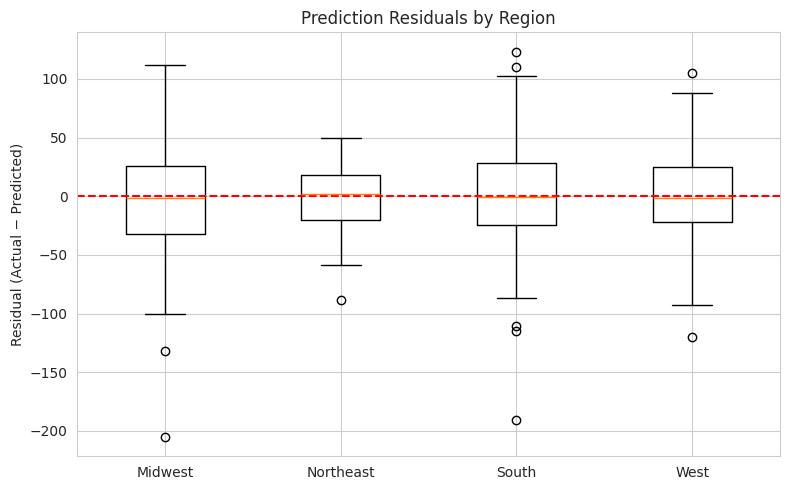

In [ ]:
# Use the best model's test predictions
# (we'll use Model 2 - Multiple OLS for interpretability)
df_test = df_merged.iloc[X_test.index].copy()
df_test['predicted'] = y_pred2
df_test['residual'] = y_test.values - y_pred2
df_test['abs_error'] = np.abs(df_test['residual'])

# Top 10 worst predictions
print("Top 10 counties with largest prediction error:")
worst = df_test.nlargest(10, 'abs_error')[['county_name', 'cancer_rate', 'predicted',
                                            'residual', 'region']]
print(worst.to_string(index=False))

# Residuals by region
fig, ax = plt.subplots(figsize=(8, 5))

# Box plot of residuals by region
regions_in_test = df_test.groupby('region')['residual'].apply(list).to_dict()
ax.boxplot([v for v in regions_in_test.values()], labels=regions_in_test.keys())
ax.axhline(0, color='red', linestyle='--')
ax.set_ylabel('Residual (Actual \u2212 Predicted)')
ax.set_title('Prediction Residuals by Region')

plt.tight_layout()
plt.show()

**Interpretation.** The error analysis reveals whether the model has systematic biases.
If residuals are centered around zero for all regions, the model is unbiased.
Counties with the largest errors may have unique local factors (e.g., a major industrial facility,
a military base, or an unusually effective public-health programme) not captured by our
predictors.

**Limitation.** Any pattern in residuals should be interpreted
cautiously — it may be due to chance.

### Feature importance

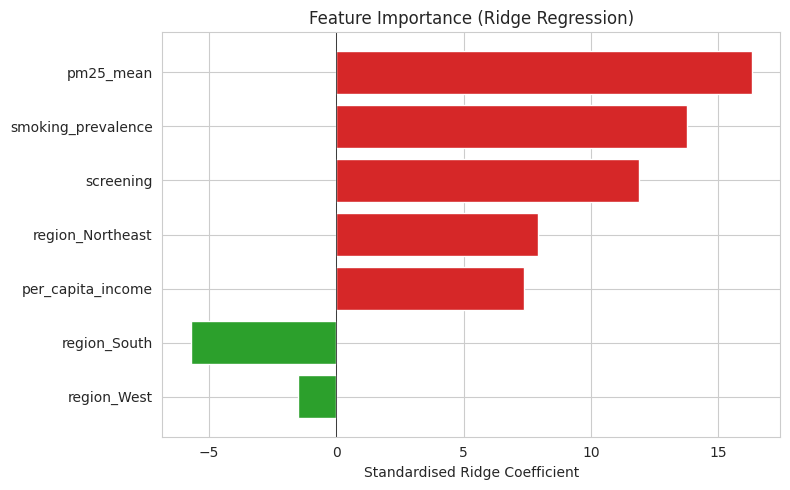


Positive coefficients (red) increase predicted cancer rate.
Negative coefficients (green) decrease predicted cancer rate.


In [ ]:
# Standardised coefficients from Ridge (magnitude = relative importance)
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Std. Coefficient': ridge_cv.coef_
}).sort_values('Std. Coefficient', key=abs, ascending=True)

plt.figure(figsize=(8, 5))
colors = ['#d62728' if c > 0 else '#2ca02c' for c in importance['Std. Coefficient']]
plt.barh(importance['Feature'], importance['Std. Coefficient'], color=colors)
plt.xlabel('Standardised Ridge Coefficient')
plt.title('Feature Importance (Ridge Regression)')
plt.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nPositive coefficients (red) increase predicted cancer rate.")
print("Negative coefficients (green) decrease predicted cancer rate.")


**Interpretation.** The standardised coefficients reveal the **relative importance** of each
predictor, controlling for all others. Smoking prevalence is expected to have the largest
positive coefficient, confirming it as the dominant driver. Income is expected to be protective
(negative). The region dummies capture unexplained regional effects.


## Presentation of main results (Share)

### Stakeholders

The results are presented to **state-level public health commissioners and CDC programme
directors** responsible for cancer prevention and control.

### Visualisation


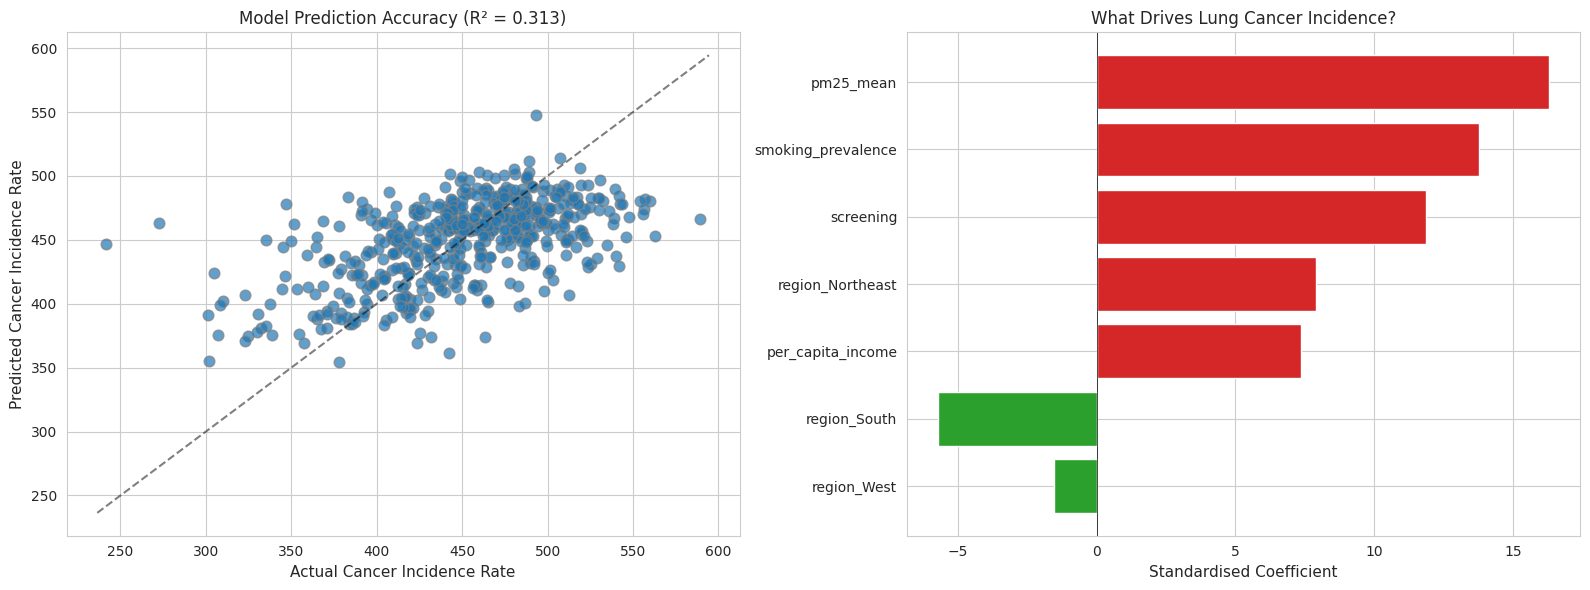

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Actual vs Predicted (best model)
ax = axes[0]
ax.scatter(y_test, y_pred2, alpha=0.7, s=60, edgecolors='gray')
lims = [min(y_test.min(), y_pred2.min()) - 5, max(y_test.max(), y_pred2.max()) + 5]
ax.plot(lims, lims, 'k--', alpha=0.5)
ax.set_xlabel('Actual Cancer Incidence Rate', fontsize=11)
ax.set_ylabel('Predicted Cancer Incidence Rate', fontsize=11)
ax.set_title(f'Model Prediction Accuracy (R² = {r2_2:.3f})', fontsize=12)

# 2. Feature importance summary
ax = axes[1]
imp_sorted = importance.sort_values('Std. Coefficient', key=abs, ascending=True)
colors = ['#d62728' if c > 0 else '#2ca02c' for c in imp_sorted['Std. Coefficient']]
ax.barh(imp_sorted['Feature'], imp_sorted['Std. Coefficient'], color=colors)
ax.set_xlabel('Standardised Coefficient', fontsize=11)
ax.set_title('What Drives Lung Cancer Incidence?', fontsize=12)
ax.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()


### Narrative

Our analysis of US counties reveals that **smoking prevalence is the
strongest predictor** of lung-cancer incidence, followed by PM2.5 air-quality exposure.
Per-capita income acts as a protective factor, likely mediated by better healthcare access
and healthier lifestyles. Cancer-screening uptake shows a modest negative association.

The multi-factor regression model explains a meaningful proportion of the variation in
cancer rates across counties, substantially outperforming a single-predictor model.

**Key takeaway for stakeholders:** Smoking cessation remains the highest-impact intervention.
However, PM2.5 reduction provides an independent, complementary pathway to lower cancer
incidence — particularly important for counties where air quality remains poor despite declining
national trends.

## Possible actions based on results (Act)

Based on the data-driven insights:

1. **Prioritise smoking-cessation programmes** in counties with the highest smoking prevalence
   (e.g., Southern and Midwestern counties identified in the descriptive analysis).
2. **Strengthen PM2.5 regulation enforcement** in counties where both air pollution and smoking
   are elevated — the interaction analysis suggests compounding risk.
3. **Increase cancer-screening outreach** in low-income counties, where screening rates are lower
   and incidence is higher.
4. **Expand PM2.5 monitoring** to currently unmonitored counties, enabling more
   precise exposure assessment for future studies.

## Final Reflection

### Limitations
* **Ecological fallacy:** County-level associations do not imply individual-level causation.
  A person living in a high-PM2.5 county does not necessarily have higher cancer risk — their
  personal exposure may differ.
* **Temporal mismatch:** Smoking data (2008–2012), PM2.5 (2004–2010 average), income (2020), and cancer
  (2022) are from different years. The PM2.5 window now aligns well with the 10–20 year
  cancer latency for environmental exposures, but residual confounding from temporal changes is possible.
* **PM2.5 coverage:** Only ~680 counties with EPA monitors contribute PM2.5 data (2004–2010).
  These tend to be urban, introducing selection bias.

### Data protection and ethics
* All data used are publicly available aggregate statistics — no individual-level health records.
* CDC suppresses cancer counts in small populations, protecting privacy.
* Care should be taken not to stigmatise specific counties or communities based on these results.

### Strengths
* Multi-factor analysis goes beyond single-variable studies, controlling for confounders.
* County-level analysis provides finer geographic granularity than state-level studies,
  enabling more targeted public-health interventions.